# Capítulo 3 — Regression & Model Assessment

Siguiendo [dmol.pub/ml/regression.html](https://dmol.pub/ml/regression.html).

Entorno: kernel `Python (dmol)`. Datos ya descargados en `../data/`.

## 3.1 De qué va este capítulo

**Regresión** = aprendizaje supervisado cuando la label es un **número real**: una solubilidad, una
energía, un pKa. Si la label fuera una categoría (tóxico / no tóxico) sería **clasificación**, que es
el capítulo 4. Lo que hicimos en el capítulo 2 ya era regresión; solo que no le pusimos nombre.

¿Qué añade entonces este capítulo? Una pregunta que dejamos abierta a propósito:

> **Todo el RMSE = 1.658 del capítulo 2 se midió sobre las mismas moléculas con las que se entrenó
> el modelo.**

Es como evaluar a un alumno con los mismos ejercicios que ha visto resueltos en clase: la nota dice
poco de si sabe la materia. El modelo lo queremos para moléculas **que no ha visto nunca**, y eso es
lo que hay que medir. Este capítulo va de cómo hacerlo bien, y de las muchas formas de hacerlo mal.

### Lo que el libro da por sabido

Dos conceptos de probabilidad que se usan en 3.4 (sesgo y varianza). Aquí van en corto y los
retomaremos allí:

| Concepto | Fórmula | En cristiano |
|---|---|---|
| **Esperanza** $E[x]$ | $\sum_x P(x)\,x$ | la media "a la larga": cada valor posible, pesado por su probabilidad |
| **Varianza** | $E\left[(x - E[x])^2\right]$ | la media de la distancia al cuadrado a la media: cuánto se dispersa. Su raíz es la desviación típica |

Analogía de laboratorio: si repites una valoración 100 veces, $E[x]$ es el valor al que tiende la
media de tus réplicas y la varianza mide cuánto bailan de una réplica a otra.

### Objetivos del capítulo, según el libro

1. Hacer regresión con muchas features usando una función de pérdida — *hecho en el capítulo 2*.
2. Entender el *batching* — *hecho en 2.3.7*.
3. Razonar sobre cómo partir los datos para evaluar.
4. Entender el **sesgo** y la **varianza** de un modelo.
5. Evaluar si un modelo **generaliza**, es decir, si funciona con datos que no ha visto.

Los dos primeros ya los tenemos. Lo nuevo son el 3, el 4 y el 5.

### Imports

Los mismos del capítulo 2, más uno nuevo:

| Import | Qué es | Para qué aquí |
|---|---|---|
| `pandas as pd` | tablas | cargar el CSV y partirlo |
| `numpy as np` | arrays y álgebra lineal | números aleatorios, mínimos cuadrados |
| `matplotlib.pyplot as plt` | gráficas | curvas de pérdida, parity plots |
| `jax`, `jax.numpy as jnp` | numpy que sabe derivar | descenso de gradiente, como en 2.3.6 |
| `rdkit.Chem`, `rdkit.Chem.Draw` | quimioinformática | leer y dibujar moléculas |
| **`MurckoScaffold`** | **nuevo.** Extrae el *esqueleto de Bemis–Murcko* de una molécula: los anillos y las cadenas que los unen, sin sustituyentes | los *scaffold splits* de 3.8.2 |

Diferencias con el código del libro:
- No hacemos `import dmol` (solo aplica el estilo de gráficas del libro).
- Leemos el CSV local en vez de descargarlo.
- El libro también importa `jax.example_libraries.optimizers`, pero ninguna celda del capítulo lo
  usa. Lo omitimos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import rdkit
import rdkit.Chem
import rdkit.Chem.Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

soldata = pd.read_csv("../data/curated-solubility-dataset.csv")
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

print(f"{len(soldata)} moléculas, {len(feature_names)} features")

9982 moléculas, 17 features


---

## 3.2 Overfitting

### El ruido: por qué los datos nunca encajan perfectos

En el capítulo 2 escribíamos la relación entre features y label como $y = f(\vec{x})$. La realidad es:

$$y = f(\vec{x}) + \epsilon$$

$\epsilon$ (épsilon) es el **ruido**: todo lo que mueve la solubilidad medida y **no** está en los 17
descriptores.

- **Error de medida.** La misma molécula medida en dos laboratorios no da lo mismo. En el
  ejercicio 10 vimos que las fuentes (`Group`) tienen sesgos propios.
- **Factores que no están en las features.** El polimorfo del sólido, la pureza, la temperatura
  real, el pH… Nada de eso aparece en `MolLogP` ni en `TPSA`.

Se supone que $\epsilon$ tiene **media 0** (no empuja siempre hacia el mismo lado) y una desviación
típica $\sigma$ **desconocida**.

La clave: el ruido es, por definición, **impredecible a partir de $\vec{x}$**. Un modelo que
"aprende" el ruido de sus datos de entrenamiento está aprendiendo algo que no se va a repetir en
moléculas nuevas. Eso es el **overfitting** (sobreajuste), y el experimento que viene lo provoca a
propósito.

### El montaje: 50 moléculas, 25 para entrenar y 25 para examinar

El libro coge **50 moléculas al azar** y las parte en dos mitades:

| Conjunto | Para qué |
|---|---|
| **Train** (entrenamiento) | el modelo lo ve: con estas moléculas se calculan los gradientes |
| **Test** (prueba) | el modelo **nunca** lo ve durante el entrenamiento. Solo sirve para medir |

¿Por qué solo 50 teniendo 9982? **Para provocar el problema.** El modelo tiene 18 parámetros
(17 pesos + el bias) y solo 25 moléculas para ajustarlos. Con tan poca información le resulta fácil
ajustarse a los caprichos de esas 25 moléculas concretas.

Tres detalles del código:

1. **`sample(50, replace=False, random_state=4)`** saca 50 filas al azar sin repetir. `random_state`
   es la **semilla**: fija la secuencia de números aleatorios, así cada ejecución saca las mismas 50.
   El libro no pone semilla, así que a cada lector le tocan moléculas distintas; nosotros la fijamos
   para que las cifras del texto coincidan con las de las celdas. Escogí la 4 porque su resultado queda
   en el centro de las semillas 0–7 (la 5.ª de 8, ordenadas por error en test) (al final de la sección están las 8, para que se vea que no es
   un caso escogido a dedo).
2. **`.copy()`** hace de `train` y `test` tablas independientes: modificarlas no toca `soldata`.
3. **Se estandariza con la media y la desviación del train, también el test.** Es el aviso de
   *data leakage* de 2.3.8, ahora en serio. Si calcularas la media con las 50 moléculas, las 25 de
   test influirían en cómo se preparan los datos de entrenamiento: el examen asomando por los apuntes.
   Y en la vida real las moléculas nuevas llegan de una en una, así que no existe una "media del
   test": se transforman con los números que ya tenías. El libro hace lo mismo con `-=` y `/=`;
   nosotros guardamos `train_mean` y `train_std` en variables para que se vea qué se reutiliza.

In [2]:
sample = soldata.sample(50, replace=False, random_state=4)
train = sample[:25].copy()
test = sample[25:].copy()

# media y desviación SOLO del train; se aplican a los dos conjuntos
train_mean = train[feature_names].mean()
train_std = train[feature_names].std()
train[feature_names] = (train[feature_names] - train_mean) / train_std
test[feature_names] = (test[feature_names] - train_mean) / train_std

x = train[feature_names].values
y = train["Solubility"].values
test_x = test[feature_names].values
test_y = test["Solubility"].values

print("train:", x.shape, "   test:", test_x.shape)
print(f"solubilidad media   train {y.mean():.2f}   test {test_y.mean():.2f}")
print(f"desviación típica   train {y.std():.2f}   test {test_y.std():.2f}")
print()
print(f"train: media de las features, en valor absoluto, como mucho {np.abs(x.mean(axis=0)).max():.1e}")
print(f"test:  valores de las features entre {test_x.min():+.1f} y {test_x.max():+.1f} desviaciones del train")

# ¿qué molécula de test está más lejos de lo que el train conoce?
col = np.abs(test_x).max(axis=0).argmax()
fila = np.abs(test_x[:, col]).argmax()
nombre_col = feature_names[col]
print()
print(f"la más extrema: {test['Name'].iloc[fila]}")
print(f"  {nombre_col} = {sample[nombre_col].iloc[25 + fila]:.0f}  →  {test_x[fila, col]:+.1f} desviaciones")
print(f"  en las 25 de train, {nombre_col} va de {sample[nombre_col].iloc[:25].min():.0f} a {sample[nombre_col].iloc[:25].max():.0f}")

train: (25, 17)    test: (25, 17)
solubilidad media   train -3.11   test -2.98
desviación típica   train 2.43   test 2.85

train: media de las features, en valor absoluto, como mucho 4.3e-16
test:  valores de las features entre -4.1 y +8.9 desviaciones del train

la más extrema: raffinose
  NumHDonors = 11  →  +8.9 desviaciones
  en las 25 de train, NumHDonors va de 0 a 4


Cómo se lee:

- **Las dos mitades no son iguales.** Train tiene solubilidad media −3.11 y desviación 2.43; test,
  −2.98 y 2.85. Con 25 moléculas basta el azar para que un conjunto salga más disperso que el otro.
- **En train, la media de cada feature queda en 0** (4·10⁻¹⁶ es cero más el error de redondeo del
  ordenador). En test no: sus features van de −4.1 a +8.9 desviaciones. Es lo esperable, porque se
  han estandarizado con números que no son los suyos.
- **La rafinosa**, un trisacárido, tiene 11 dadores de puente de hidrógeno (sus OH). Entre las 25
  moléculas de train, la que más tiene llega a 4. El modelo tendrá que predecir una molécula que
  está **8.9 desviaciones** fuera de todo lo que ha visto. Apúntala, que vuelve a salir.

### La pérdida y un punto de partida aleatorio

La pérdida es el mismo MSE del capítulo 2, con una novedad: **`@jax.jit`**.

- Una línea con `@` encima de un `def` es un **decorador**: envuelve la función en otra que le añade
  comportamiento. Aquí el comportamiento es `jax.jit`.
- **JIT** = *just-in-time compilation*. La primera vez que llamas a `loss`, JAX traduce la función a
  código máquina optimizado para esas formas de array; las siguientes llamadas usan directamente la
  versión compilada. Vamos a llamarla 4000 veces (train y test en cada paso), así que compensa.
- No cambia **qué** se calcula, solo lo rápido que va.

Los pesos iniciales ya no son ceros sino **números aleatorios** sacados de una normal de media 0 y
desviación 1. Con features estandarizadas es una escala razonable, y es como se inicializan las redes
neuronales del capítulo 6. También aquí fijamos la semilla (`np.random.default_rng(4)`); el libro usa
`np.random.normal` sin semilla.

In [3]:
@jax.jit
def loss(w, b, x, y):
    return jnp.mean((y - jnp.dot(x, w) - b) ** 2)


loss_grad = jax.grad(loss, (0, 1))

rng = np.random.default_rng(4)
w = rng.normal(size=x.shape[1])   # 17 pesos aleatorios
b = 0.0

print("pesos iniciales:", w.round(2))
print(f"pérdida inicial   train {loss(w, b, x, y):.2f}   test {loss(w, b, test_x, test_y):.2f}")

pesos iniciales: [-0.65 -0.17  1.66  0.66 -1.64 -0.01 -0.62  0.15 -1.61  0.24  0.24  1.58
  0.32  0.51 -1.49  2.25 -1.92]


pérdida inicial   train 30.73   test 59.04


### Entrenar vigilando las dos pérdidas

El bucle es el descenso de gradiente de 2.3.6, con $\eta = 0.05$ y 2000 pasos. Lo nuevo es que en
**cada paso** apuntamos dos números:

- **pérdida de train**: la que el algoritmo está minimizando;
- **pérdida de test**: la calculamos solo para mirarla. Fíjate en el código: `loss_grad` recibe
  `x, y` y **nunca** `test_x, test_y`. El test no mueve ningún peso.

El eje vertical va en **escala logarítmica** (`set_yscale("log")`): cada marca vale 10 veces la
anterior. Hace falta porque la pérdida pasa de ~20 a menos de 1, y en escala lineal toda la parte
interesante quedaría aplastada contra el suelo.

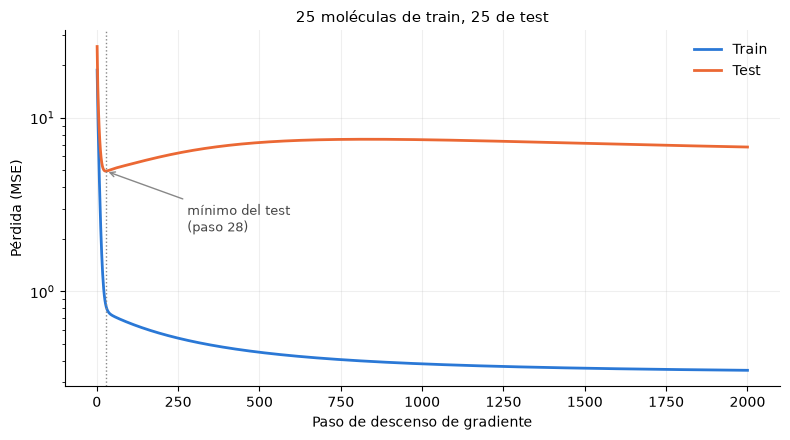

  paso  loss train  loss test  RMSE train  RMSE test
     1      18.774     25.663       4.333      5.066
    10       3.112      6.958       1.764      2.638
    28       0.829      4.925       0.910      2.219
   100       0.658      5.381       0.811      2.320
   500       0.447      7.195       0.669      2.682
  2000       0.352      6.777       0.593      2.603

mínimo del test en el paso 28; máximo posterior en el paso 833 (loss 7.51)
al final, la pérdida de test es 19.3 veces la de train


In [4]:
loss_progress = []
test_loss_progress = []
eta = 0.05
for i in range(2000):
    grad = loss_grad(w, b, x, y)
    w -= eta * grad[0]
    b -= eta * grad[1]
    loss_progress.append(float(loss(w, b, x, y)))
    test_loss_progress.append(float(loss(w, b, test_x, test_y)))

loss_progress = np.array(loss_progress)
test_loss_progress = np.array(test_loss_progress)
pasos = np.arange(1, len(loss_progress) + 1)
paso_min = int(test_loss_progress.argmin()) + 1          # contando desde 1
pico = paso_min + int(test_loss_progress[paso_min:].argmax()) + 1

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(pasos, loss_progress, color="#2a78d6", linewidth=2, label="Train")
ax.plot(pasos, test_loss_progress, color="#eb6834", linewidth=2, label="Test")
ax.axvline(paso_min, color="#888", linestyle=":", linewidth=1)
ax.annotate(f"mínimo del test\n(paso {paso_min})",
            xy=(paso_min, test_loss_progress[paso_min - 1]),
            xytext=(paso_min + 250, test_loss_progress[paso_min - 1] * 0.45),
            fontsize=9, color="#444", arrowprops=dict(arrowstyle="->", color="#888"))
ax.set_yscale("log")
ax.set_xlabel("Paso de descenso de gradiente")
ax.set_ylabel("Pérdida (MSE)")
ax.set_title("25 moléculas de train, 25 de test", fontsize=11)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/03_curva_overfitting.png", dpi=150)
plt.show()

print(f"{'paso':>6s} {'loss train':>11s} {'loss test':>10s} {'RMSE train':>11s} {'RMSE test':>10s}")
for p in sorted({1, 10, paso_min, 100, 500, 2000}):
    lt, le = loss_progress[p - 1], test_loss_progress[p - 1]
    print(f"{p:6d} {lt:11.3f} {le:10.3f} {np.sqrt(lt):11.3f} {np.sqrt(le):10.3f}")
print()
print(f"mínimo del test en el paso {paso_min}; máximo posterior en el paso {pico} (loss {test_loss_progress[pico - 1]:.2f})")
print(f"al final, la pérdida de test es {test_loss_progress[-1] / loss_progress[-1]:.1f} veces la de train")

La curva tiene dos fases, separadas por la línea de puntos:

| Paso | Loss train | Loss test | Qué pasa |
|---|---|---|---|
| 1 | 18.77 | 25.66 | punto de partida (pesos aleatorios) |
| 10 | 3.11 | 6.96 | las dos bajan juntas |
| **28** | **0.83** | **4.93** | **mínimo del test** |
| 100 | 0.66 | 5.38 | train sigue bajando; test ya sube |
| 500 | 0.45 | 7.20 | |
| 2000 | 0.35 | 6.78 | |

1. **Pasos 1 a 28: aprende de verdad.** Las dos pérdidas caen a la vez. Lo que el modelo saca de las
   25 moléculas de train también sirve para las otras 25, así que es química que se generaliza:
   lipofilia, tamaño, polaridad.
2. **Del paso 28 en adelante: memoriza.** La pérdida de train sigue bajando (0.83 → 0.35), pero la de
   test **sube**, hasta 7.51 en el paso 833, y luego baja un poco hasta 6.78. Lo que el modelo ajusta
   ahora son las particularidades de esas 25 moléculas concretas —su ruido—, y eso no le sirve para
   ninguna otra.

Al final, la pérdida de test es **19 veces** la de train. Esa brecha entre las dos curvas es la firma
del overfitting. Y fíjate en que, si solo hubiéramos mirado la curva azul, diríamos que el
entrenamiento va de maravilla: **la pérdida de train no avisa de nada**.

Una consecuencia práctica: parando en el paso 28 tendríamos el mejor modelo para moléculas nuevas.
Eso tiene nombre, *early stopping* (parada temprana), y es una técnica estándar en redes neuronales.
Pero hay una trampa: para saber que el mejor paso es el 28 hemos **mirado el test**, y un test que
se usa para tomar decisiones deja de ser un examen limpio. La solución habitual es apartar un tercer
conjunto, el de **validación**, solo para esas decisiones.

### Parity plots: train frente a test

El parity plot de 2.3.9 (real en el eje X, predicho en el eje Y, perfecto = sobre la diagonal), ahora
con el modelo del paso 2000 y en dos paneles: las 25 moléculas que el modelo ha visto y las 25 que no.

En cada panel, el **RMSE** y la **correlación** $r$ entre real y predicho. El libro rotula ese primer
número como `loss`, pero calcula la raíz: es el RMSE. Y para tener un listón, imprimimos también el
RMSE del modelo tonto de 2.3.5, "predecir siempre la media", usando la media **del train** (la única
que el modelo conoce).

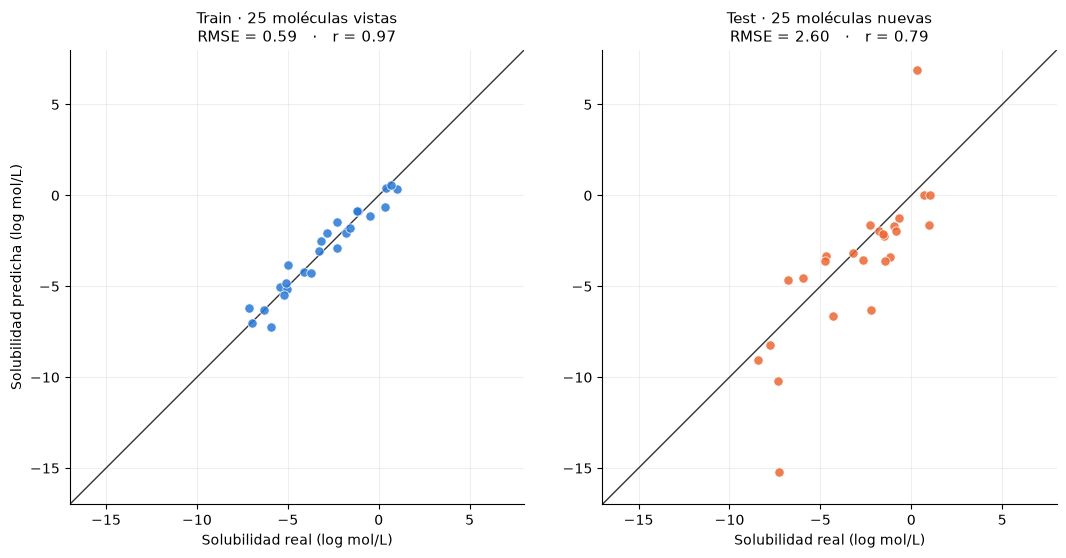

train  RMSE modelo 0.593   RMSE 'predecir la media' 2.426   r 0.970
test   RMSE modelo 2.603   RMSE 'predecir la media' 2.854   r 0.793

test: real entre -8.42 y 1.01;  predicho entre -15.20 y 6.92

los 3 peores del test:
  4-chloro-N-(5-chloro-2-methylphenyl)-3-[(E)-2 real  -7.26   predicho -15.20   error 7.93
  raffinose                                     real   0.30   predicho   6.92   error 6.62
  oxaprozin;  4,5-diphenyl-2-oxazolepropanoic a real  -2.24   predicho  -6.29   error 4.05

RMSE test quitando solo la peor: 2.107


In [5]:
yhat = x @ w + b
test_yhat = test_x @ w + b


def rmse_y_r(real, pred):
    return np.sqrt(np.mean((real - pred) ** 2)), np.corrcoef(real, pred)[0, 1]


todos = np.concatenate([y, yhat, test_y, test_yhat])
lims = (np.floor(todos.min()) - 1, np.ceil(todos.max()) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
paneles = [(axes[0], y, yhat, "Train · 25 moléculas vistas", "#2a78d6"),
           (axes[1], test_y, test_yhat, "Test · 25 moléculas nuevas", "#eb6834")]
for ax, real, pred, titulo, color in paneles:
    rmse, r = rmse_y_r(real, pred)
    ax.plot(lims, lims, color="#333", linewidth=1)
    ax.scatter(real, pred, s=45, color=color, alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_title(f"{titulo}\nRMSE = {rmse:.2f}   ·   r = {r:.2f}", fontsize=11)
    ax.set_xlabel("Solubilidad real (log mol/L)")
    ax.grid(alpha=0.2)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("Solubilidad predicha (log mol/L)")
fig.tight_layout()
fig.savefig("../figuras/03_parity_train_test.png", dpi=150)
plt.show()

media_train = y.mean()
for nombre, real, pred in [("train", y, yhat), ("test", test_y, test_yhat)]:
    rmse, r = rmse_y_r(real, pred)
    rmse_media = np.sqrt(np.mean((real - media_train) ** 2))
    print(f"{nombre:5s}  RMSE modelo {rmse:.3f}   RMSE 'predecir la media' {rmse_media:.3f}   r {r:.3f}")

print(f"\ntest: real entre {test_y.min():.2f} y {test_y.max():.2f};  predicho entre {test_yhat.min():.2f} y {test_yhat.max():.2f}")

errores = np.abs(test_yhat - test_y)
print("\nlos 3 peores del test:")
for i in np.argsort(errores)[::-1][:3]:
    print(f"  {test['Name'].iloc[i][:45]:45s} real {test_y[i]:6.2f}   predicho {test_yhat[i]:6.2f}   error {errores[i]:.2f}")
sin_peor = np.arange(len(test_y)) != errores.argmax()
print(f"\nRMSE test quitando solo la peor: {np.sqrt(np.mean(errores[sin_peor] ** 2)):.3f}")

Los dos paneles, en números:

| | RMSE modelo | RMSE "predecir la media" | $r$ |
|---|---|---|---|
| **Train** | 0.59 | 2.43 | 0.97 |
| **Test** | 2.60 | 2.85 | 0.79 |

- **En train el modelo parece excelente**: puntos pegados a la diagonal, $r = 0.97$ y un error cuatro
  veces menor que el del modelo tonto.
- **En test esa ventaja casi desaparece**: 2.60 frente a 2.85, apenas un 9 % mejor que no mirar la
  molécula. Lo que parecía un gran modelo era, sobre todo, memoria.
- **Predicciones imposibles.** La rafinosa, con solubilidad real +0.30, recibe una predicción de
  **+6.92**: unos 8 millones de mol/L, cuando el agua pura tiene 55 mol/L. En el otro extremo, un
  pigmento bis-azoico con cuatro cloros (el nombre larguísimo; 917 g/mol) tiene −7.26 y recibe
  **−15.20**, más insoluble que cualquiera de las 9982 moléculas del dataset (la mínima era −13.17).
- **El RMSE lo dominan unos pocos.** Con quitar solo la peor molécula, el RMSE de test baja de 2.60 a
  2.11. El error va al cuadrado, así que dos o tres fallos gordos pesan más que veinte aciertos.
- **$r = 0.79$ no contradice lo anterior.** $r$ mide si el **orden** es correcto (insolubles abajo,
  solubles arriba), no si los valores tienen la escala buena. Las dos predicciones extremas van en la
  dirección correcta, pero exageradas: se alejan de la media del train unas tres veces más de lo que
  deberían.

#### ¿Por qué fallan justo esas? *(variante propia)*

La rafinosa ya la habíamos señalado como la molécula de test más alejada del train. La sospecha: los
fallos grandes se concentran en moléculas **fuera del rango** que el modelo conoce.

Para comprobarlo, marcamos una molécula de test como "fuera de rango" si **alguna** de sus 17
features queda por debajo del mínimo o por encima del máximo de esa feature en las 25 de train. Lo
hacemos con los valores sin estandarizar (`sample`); estandarizar no cambia qué queda fuera. Después
comparamos el RMSE de los dos grupos.

In [6]:
crudo_train = sample[:25][feature_names]
crudo_test = sample[25:][feature_names]
fuera = (crudo_test < crudo_train.min()) | (crudo_test > crudo_train.max())
n_fuera = fuera.sum(axis=1).values          # cuántas de las 17 features se salen, por molécula

diagnostico = pd.DataFrame({
    "molécula": test["Name"].str[:32].values,
    "error": errores,
    "features fuera de rango": n_fuera,
}).sort_values("error", ascending=False)
print(diagnostico.round(2).to_string(index=False))

dentro = n_fuera == 0
print()
print(f"{(~dentro).sum():2d} moléculas con alguna feature fuera de rango → RMSE {np.sqrt(np.mean(errores[~dentro] ** 2)):.3f}")
print(f"{dentro.sum():2d} moléculas dentro del rango del train      → RMSE {np.sqrt(np.mean(errores[dentro] ** 2)):.3f}")

                        molécula  error  features fuera de rango
4-chloro-N-(5-chloro-2-methylphe   7.93                       12
                       raffinose   6.62                        7
oxaprozin;  4,5-diphenyl-2-oxazo   4.05                        0
                   tetrafluthrin   2.88                        1
          2-chloropropionic acid   2.60                        0
3,3'-[[4-[(2-chloro-4-nitropheny   2.34                        2
N-(4-fluorophenyl)-2-hydroxy-N-p   2.23                        0
    5-oxo-3-phenyl-hexanoic acid   2.18                        0
               hexadecanoic acid   2.18                        0
                   pendimethalin   1.43                        1
                     bayer 15080   1.33                        0
                       kinoprene   1.09                        1
  2-methoxy-3,4-dihydro-2H-pyran   1.09                        0
        potassium cyanosulfanide   1.00                        4
3-methyl-2-propyl-2,3-dih

Confirmado, con matices:

- Las dos peores se salen del rango en **12** y **7** features. El pigmento (917 g/mol) es mucho más
  grande que cualquier molécula del train; la rafinosa tiene muchos más OH.
- Las 10 moléculas que se salen en algo tienen **RMSE 3.55**; las 15 que caen dentro, **1.70**. El doble.
- Pero no es una regla perfecta. La tercera peor (la oxaprozina, error 4.05) está **dentro** del rango
  en las 17 features. Y al revés: el formiato de metilo se sale en 6 y falla solo por 0.70.

Por qué un modelo lineal extrapola tan mal: la predicción es una suma de peso × feature, y una suma
no tiene freno. Si una feature vale 8.9 desviaciones en lugar de las 1–2 habituales, su término crece
en proporción, y nada en el modelo sabe que la solubilidad tiene un techo físico.

Esta idea —que un modelo solo es fiable dentro de la zona de datos que ha visto— tiene nombre:
**dominio de aplicabilidad**. El libro la trata en 3.8.

### Qué es, entonces, el overfitting

La definición del libro: el resultado de **entrenar demasiados pasos o con demasiados parámetros**,
de forma que el modelo **aprende el ruido** de los datos de entrenamiento.

La analogía del alumno que se aprende de memoria las soluciones de los 25 ejercicios resueltos: saca
un 10 en esos, y en el examen, con ejercicios nuevos, lo hace peor que uno que solo entendió la idea
general. Y lo hace peor precisamente porque aplica con toda confianza "reglas" que solo valían para
aquellos 25.

Por qué aquí era tan fácil:

| | Capítulo 2 | Este experimento |
|---|---|---|
| moléculas de entrenamiento | 9982 | 25 |
| parámetros | 18 | 18 |
| moléculas por parámetro | ~555 | ~1.4 |

Con 555 moléculas por parámetro, el ruido de unas se compensa con el de otras (media 0) y el modelo
solo puede quedarse con la tendencia común. Con 1.4, cada parámetro puede dedicarse a explicar el
capricho de un par de moléculas.

¿Significa esto que el 1.658 del capítulo 2 está a salvo? **Todavía no lo sabemos** — lo mediremos en
3.6. Y en 3.2.1 el libro separa con datos sintéticos los ingredientes que hacen falta para sobreajustar:
ruido, features de más o mal correlacionadas, y entrenar hasta converger.

### Variante propia: ¿ha sido cosa de la semilla?

*(No está en el libro.)*

Todo lo anterior sale de **un** sorteo de 50 moléculas. Con 25 datos, otro sorteo puede contar otra
historia. Repetimos el experimento completo con las semillas 0 a 7 (la misma semilla para elegir las
moléculas y para los pesos iniciales) y dibujamos cada uno en su panel.

Esto se llama *small multiples*: la misma gráfica repetida con los mismos ejes, un caso por panel,
para comparar formas de un vistazo sin amontonar 16 curvas en una.

`experimento(seed)` es exactamente el código de arriba metido en una función; con `seed=4` reproduce
la curva que ya hemos visto.

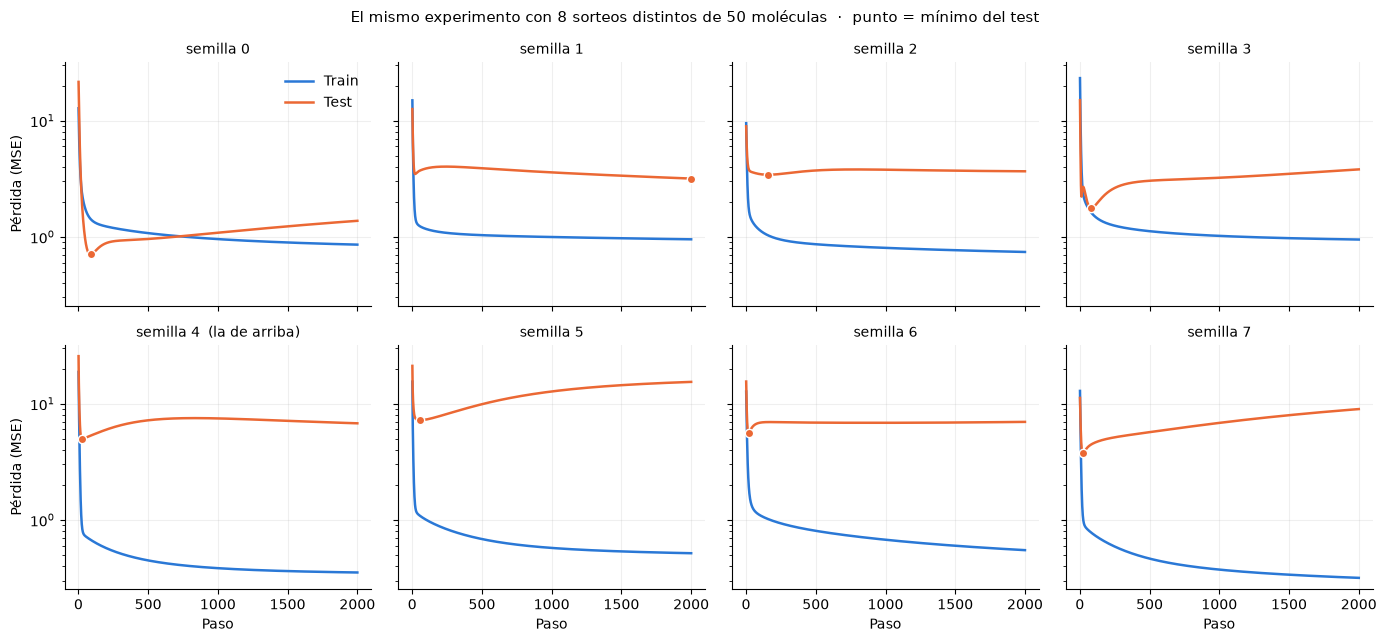

         paso mín. test  RMSE test mín.  RMSE train final  RMSE test final  RMSE 'predecir media' ¿test final peor que la media?
semilla                                                                                                                         
0                    87           0.839             0.925            1.171                  1.996                             no
1                  2000           1.780             0.975            1.780                  2.858                             no
2                   159           1.849             0.860            1.914                  3.034                             no
3                    83           1.332             0.973            1.950                  2.400                             no
4                    28           2.219             0.593            2.603                  2.854                             no
5                    59           2.686             0.718            3.925                  2.065

In [7]:
def experimento(seed, n_pasos=2000, eta=0.05):
    # Repite el montaje de 3.2 con otra semilla. Devuelve las dos curvas y el listón del test
    muestra = soldata.sample(50, replace=False, random_state=seed)
    tr, te = muestra[:25].copy(), muestra[25:].copy()
    media, desv = tr[feature_names].mean(), tr[feature_names].std()
    tr[feature_names] = (tr[feature_names] - media) / desv
    te[feature_names] = (te[feature_names] - media) / desv
    xs, ys = tr[feature_names].values, tr["Solubility"].values
    txs, tys = te[feature_names].values, te["Solubility"].values

    ws = np.random.default_rng(seed).normal(size=xs.shape[1])
    bs = 0.0
    curva_tr, curva_te = [], []
    for _ in range(n_pasos):
        g = loss_grad(ws, bs, xs, ys)
        ws -= eta * g[0]
        bs -= eta * g[1]
        curva_tr.append(float(loss(ws, bs, xs, ys)))
        curva_te.append(float(loss(ws, bs, txs, tys)))
    rmse_media = float(np.sqrt(np.mean((tys - ys.mean()) ** 2)))
    return np.array(curva_tr), np.array(curva_te), rmse_media


semillas = range(8)
resultados = {s: experimento(s) for s in semillas}

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), sharex=True, sharey=True)
filas = []
for ax, s in zip(axes.flat, semillas):
    c_tr, c_te, rmse_media = resultados[s]
    p_min = int(c_te.argmin()) + 1
    ax.plot(pasos, c_tr, color="#2a78d6", linewidth=1.8, label="Train")
    ax.plot(pasos, c_te, color="#eb6834", linewidth=1.8, label="Test")
    ax.plot(p_min, c_te[p_min - 1], "o", color="#eb6834", markersize=6, markeredgecolor="white")
    ax.set_yscale("log")
    ax.set_title(f"semilla {s}" + ("  (la de arriba)" if s == 4 else ""), fontsize=10)
    ax.grid(alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    filas.append({"semilla": s, "paso mín. test": p_min,
                  "RMSE test mín.": np.sqrt(c_te.min()),
                  "RMSE train final": np.sqrt(c_tr[-1]),
                  "RMSE test final": np.sqrt(c_te[-1]),
                  "RMSE 'predecir media'": rmse_media})
axes[0, 0].legend(frameon=False)
for ax in axes[1]:
    ax.set_xlabel("Paso")
for ax in axes[:, 0]:
    ax.set_ylabel("Pérdida (MSE)")
fig.suptitle("El mismo experimento con 8 sorteos distintos de 50 moléculas  ·  punto = mínimo del test", fontsize=11)
fig.tight_layout()
fig.savefig("../figuras/03_overfitting_semillas.png", dpi=150)
plt.show()

tabla = pd.DataFrame(filas).set_index("semilla")
tabla["¿test final peor que la media?"] = np.where(tabla["RMSE test final"] > tabla["RMSE 'predecir media'"], "sí", "no")
print(tabla.round(3).to_string())

Qué dicen los 8 paneles:

- **La brecha aparece en los 8.** Al final, el RMSE de test supera al de train en todos: el de train
  queda entre 0.56 y 0.98, el de test entre 1.17 y 3.93.
- **En 7 de 8, el test toca fondo pronto** (entre los pasos 18 y 159) y luego empeora. La excepción es
  la **semilla 1**: su test sube un poco al principio y después vuelve a bajar despacio, así que su
  mínimo es el último paso. En 2000 pasos, ese sorteo no llega a sobreajustar (aunque la brecha
  existe: 0.98 en train frente a 1.78 en test).
- **En 3 de 8 (semillas 5, 6 y 7), el modelo final es peor en test que predecir la media.** En la 6 y
  la 7, el modelo del mínimo sí batía a la media: los 2000 pasos han estropeado un modelo útil. La 5
  no la bate ni en su mejor paso (2.69 frente a 2.07).
- **La misma receta da resultados muy distintos.** El RMSE de test final va de 1.17 a 3.93 solo por
  cambiar qué 50 moléculas salieron. En la semilla 0 el test llega a 0.84, **por debajo** del train
  (0.93): a veces el examen sale fácil. Con 25 moléculas de test, **la propia medida del error es
  ruidosa**.

Ese último punto es el problema que resuelve la **validación cruzada** (3.6): no fiarse de un único
reparto train/test.

### Resumen de 3.1 y de la introducción de 3.2

- **Regresión** = aprendizaje supervisado con label real. Lo del capítulo 2 ya lo era.
- Las labels llevan **ruido**: $y = f(\vec{x}) + \epsilon$, con $\epsilon$ de media 0 e impredecible a
  partir de $\vec{x}$.
- **Train / test**: el test nunca entra en los gradientes, y se estandariza con la media y la
  desviación **del train**.
- **Firma del overfitting**: la pérdida de train sigue bajando mientras la de test sube. La de train,
  sola, no avisa.
- Con 25 moléculas y 18 parámetros: RMSE 0.59 en train y 2.60 en test, apenas mejor que predecir la
  media (2.85).
- Los peores fallos son **extrapolaciones**: moléculas fuera del rango del train (RMSE 3.55 frente a 1.70).
- Un único reparto de 25 moléculas mide el error con mucho ruido: entre 1.17 y 3.93 según el sorteo.

**Siguiente**: 3.2.1, overfitting con datos sintéticos. Con un polinomio conocido, el libro separa qué
hace falta para sobreajustar: ruido, features que sobran o están mal correlacionadas, y entrenar hasta
converger.

---

### 3.2.1 Overfitting con datos sintéticos

#### Por qué inventarse los datos

Con la solubilidad real hay dos cosas que **no sabemos**: cuál es la función verdadera $f$ y cuánto
ruido $\epsilon$ lleva cada medida. Por eso en 3.2 solo pudimos ver *que* el modelo sobreajustaba, no
*por qué*.

Con datos **sintéticos** (inventados por nosotros) conocemos las dos cosas y podemos encenderlas y
apagarlas una a una, como en un experimento con controles. El libro elige un polinomio:

$$f(x) = x^3 - x^2 + x - 1$$

Aunque la curva no es una recta, esto **es un modelo lineal** en el sentido del ejercicio 3 del
capítulo 2: lineal en los **pesos**, no en $x$. Basta con tomar como features las cuatro columnas
$[x^3,\ x^2,\ x,\ 1]$:

$$f(x) = \underbrace{1}_{w_1}\cdot x^3 + \underbrace{(-1)}_{w_2}\cdot x^2 + \underbrace{1}_{w_3}\cdot x + \underbrace{(-1)}_{w_4}\cdot 1$$

Si el modelo aprende bien, los pesos deberían salir $[1, -1, 1, -1]$.

Un detalle: la última columna es un 1 constante, así que su peso **hace de bias** $b$. Por eso, cuando
calculemos la pérdida, pasaremos `b = 0` a la función `loss` de 3.2: el bias ya va dentro de `w`.

#### Generar los datos

| Código | Qué hace |
|---|---|
| `np.linspace(-3, 3, N)` | `N` números **equiespaciados** de −3 a 3, ambos incluidos (a diferencia de `range`, que no incluye el final) |
| `syn_x**3` | eleva **cada elemento** del array al cubo (operación elemento a elemento, como en el capítulo 1) |
| `np.ones_like(syn_x)` | un array de unos con la misma forma que `syn_x`: la columna del bias |
| `np.vstack([...])` | apila los 4 arrays **como filas**: sale una matriz de forma (4, 20) |
| `.T` | la traspuesta: (4, 20) → (20, 4). Una fila por punto y una columna por feature, que es la convención de siempre |

Las labels son la función exacta, **sin ruido** de momento. El prefijo `syn_` (de *synthetic*) es del
libro, para no pisar las variables de las moléculas.

In [8]:
# generate data from polynomial
N = 20
syn_x = np.linspace(-3, 3, N)
# create feature matrix
syn_features = np.vstack([syn_x**3, syn_x**2, syn_x, np.ones_like(syn_x)]).T
syn_labels = syn_x**3 - syn_x**2 + syn_x - 1

print("forma de syn_features:", syn_features.shape)
print(pd.DataFrame(syn_features, columns=["x^3", "x^2", "x", "1"])
      .assign(label=syn_labels).round(2).head(4).to_string())

forma de syn_features: (20, 4)
     x^3   x^2     x    1  label
0 -27.00  9.00 -3.00  1.0 -40.00
1 -19.34  7.20 -2.68  1.0 -30.23
2 -13.29  5.61 -2.37  1.0 -22.26
3  -8.65  4.21 -2.05  1.0 -15.91


#### El reparto: los extremos para entrenar, el centro para examinar

A diferencia de 3.2, aquí el reparto **no es al azar**. De los 20 puntos (índices 0 a 19):

| Conjunto | Índices | Código |
|---|---|---|
| **Train** | 0–4 y 15–19 (los 5 de cada extremo) | `range(0, N // 4)` + `range(3 * N // 4, N)` |
| **Test** | 5–14 (los 10 del centro) | `range(N // 4, 3 * N // 4)` |

`//` es la **división entera**: `20 // 4 = 5` y `3 * 20 // 4 = 15`. Y recuerda que `range(a, b)` va de
`a` a `b - 1`.

Así el modelo tiene que **rellenar un hueco**: nunca ve ningún punto entre −1.74 y 1.74, y se le
examina justo ahí. Es una prueba exigente a propósito. En química sería como entrenar solo con
moléculas muy pequeñas y muy grandes y preguntar por las medianas.

Aviso: este bloque **reutiliza los nombres `test_x`, `test_y` y `w`** de 3.2 (lo hace el libro), así que
las celdas de 3.2 dejan de funcionar si se re-ejecutan sueltas después de estas. Reejecutando el
notebook de arriba abajo no hay problema.

In [9]:
# split data into train/test
indices = list(range(0, N // 4)) + list(range(3 * N // 4, N))
test_indices = list(range(N // 4, 3 * N // 4))
train_x = syn_features[indices]
train_y = syn_labels[indices]
test_x = syn_features[test_indices]
test_y = syn_labels[test_indices]

print("x de train:", syn_x[indices].round(2))
print("x de test: ", syn_x[test_indices].round(2))
print(f"labels de train entre {train_y.min():.1f} y {train_y.max():.1f}")
print(f"labels de test  entre {test_y.min():.1f} y {test_y.max():.1f}")

x de train: [-3.   -2.68 -2.37 -2.05 -1.74  1.74  2.05  2.37  2.68  3.  ]
x de test:  [-1.42 -1.11 -0.79 -0.47 -0.16  0.16  0.47  0.79  1.11  1.42]
labels de train entre -40.0 y 20.0
labels de test  entre -7.3 y 1.3


#### Ajustar sin descenso de gradiente: `np.linalg.lstsq`

En el capítulo 2 encontramos los pesos **bajando paso a paso** por la pérdida. Para el MSE de un
modelo lineal hay un atajo: el mínimo tiene una **fórmula cerrada** (las *ecuaciones normales* de
mínimos cuadrados), y `np.linalg.lstsq` ("*least squares*") la resuelve directamente. Es el "óptimo
exacto" con el que comparamos en 2.3.8.

- Ventaja: da el mínimo exacto, sin elegir $\eta$ ni número de pasos.
- Consecuencia importante para esta sección: **aquí no hay "entrenar demasiados pasos"**. El modelo
  llega directamente al fondo, así que todo el overfitting que veamos vendrá de **los datos y las
  features**, no del tiempo de entrenamiento.

`lstsq` devuelve cuatro cosas (la solución, la suma de residuos, el rango de la matriz y sus valores
singulares). Solo queremos la primera: `w, *_ = ...` guarda la primera en `w` y las demás en `_`, que
en Python es el nombre convencional de "esto lo tiro".

**Las gráficas.** El libro repite el mismo código de dibujo en los cuatro escenarios. Aquí lo metemos
en una función, `grafica_sintetica`, para no copiarlo cuatro veces. Dibuja:

| Elemento | Qué es |
|---|---|
| puntos azules | labels de train (las que ve `lstsq`) |
| puntos naranjas | labels de test (siempre **sin ruido**: son la función verdadera) |
| línea verde | la predicción del modelo en los 20 valores de $x$ |
| línea gris discontinua | la función verdadera $f(x)$ |

Además escribe la pérdida (MSE) de train y de test con la `loss` de 3.2. Diferencias con el libro: la
paleta del proyecto, y el eje Y va de −50 a 30 en vez de −40 a 40, para que no se corte ningún punto
de train cuando añadamos ruido.

pesos: [ 1. -1.  1. -1.]  (los verdaderos son [1, -1, 1, -1])


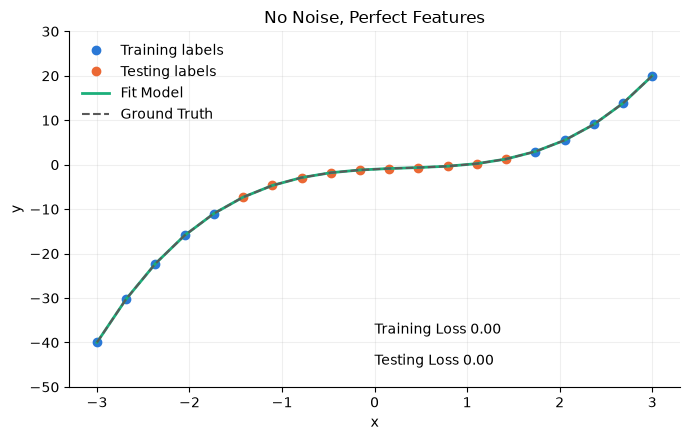

In [10]:
def grafica_sintetica(w, titulo, archivo, legend_loc="best"):
    # Dibuja un escenario de 3.2.1 y devuelve (loss train, loss test)
    loss_tr = float(loss(w, 0, train_x, train_y))
    loss_te = float(loss(w, 0, test_x, test_y))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(syn_x[indices], train_y, "o", color="#2a78d6", label="Training labels")
    ax.plot(syn_x[test_indices], test_y, "o", color="#eb6834", label="Testing labels")
    ax.plot(syn_x, syn_features @ w, color="#1baf7a", linewidth=2, label="Fit Model")
    ax.plot(syn_x, syn_labels, "--", color="0.35", label="Ground Truth")
    ax.set_ylim(-50, 30)
    ax.text(0, -38, f"Training Loss {loss_tr:.2f}")
    ax.text(0, -45, f"Testing Loss {loss_te:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(titulo)
    ax.legend(loc=legend_loc, frameon=False)
    ax.grid(alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    fig.tight_layout()
    fig.savefig(f"../figuras/{archivo}", dpi=150)
    plt.show()
    return loss_tr, loss_te


# fit using numpy least squares method.
w, *_ = np.linalg.lstsq(train_x, train_y)
print("pesos:", w.round(4), " (los verdaderos son [1, -1, 1, -1])")
resultados_syn = {}
resultados_syn["1. sin ruido, features perfectas"] = grafica_sintetica(
    w, "No Noise, Perfect Features", "03_sint_1_sin_ruido.png")

**Escenario 1: sin ruido y con las features exactas.** Todo perfecto:

- `lstsq` recupera los pesos verdaderos $[1, -1, 1, -1]$.
- Pérdida de train **0.00** y de test **0.00**: la línea verde tapa por completo a la gris.

Aunque el modelo nunca ha visto el centro, lo predice sin error. Si las features son las correctas y
los datos no tienen ruido, 10 puntos sobran para fijar 4 pesos, y con los pesos exactos da igual dónde
se pregunte.

Es el control positivo del experimento: **sin ruido y con las features adecuadas no hay overfitting**.

#### Escenario 2: añadir ruido a las labels de train

Ahora sumamos ruido **solo a las labels de train**: a cada una, un número sacado de una normal de media 0
y desviación típica 5 (`scale=5`). Es el $\epsilon$ de $y = f(x) + \epsilon$.

Para hacerse una idea del tamaño: las labels de train van de −40 a 20, así que un ruido de ±5 es
apreciable pero no domina.

Las labels de **test se quedan sin ruido**. Es un lujo que solo dan los datos sintéticos: la pérdida de
test mide entonces **únicamente cuánto se aleja $\hat{f}$ de la $f$ verdadera**, sin error de medida
por medio.

El libro usa `np.random.normal` sin semilla. Nosotros usamos `np.random.default_rng(4)`, como en el
resto del capítulo, para que las cifras de este texto no cambien al reejecutar. Al final de la sección
comprobamos qué pasa con otras semillas.

In [11]:
rng_syn = np.random.default_rng(4)
ruido = rng_syn.normal(scale=5, size=train_y.shape)
train_y = train_y + ruido

print("ruido añadido:", ruido.round(2))
print("labels de train con ruido:", train_y.round(1))

ruido añadido: [-3.26 -0.87  8.32  3.3  -8.21 -0.03 -3.12  0.74 -8.04  1.21]
labels de train con ruido: [-43.3 -31.1 -13.9 -12.6 -19.2   2.9   2.4   9.8   5.8  21.2]


pesos: [ 1.075 -0.958  0.114 -2.242]  (los verdaderos son [1, -1, 1, -1])


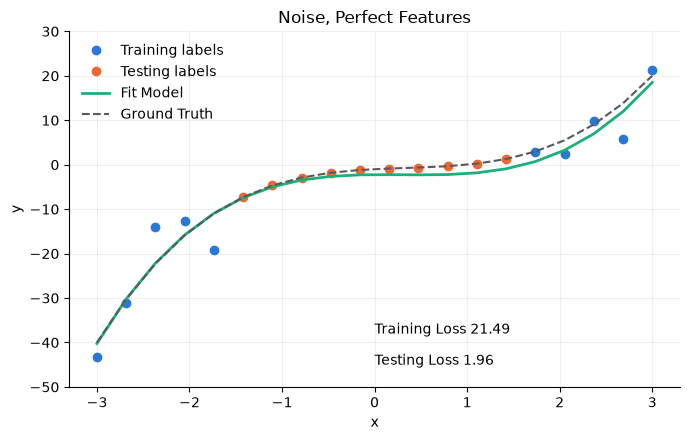

In [12]:
w, *_ = np.linalg.lstsq(train_x, train_y)
print("pesos:", w.round(3), " (los verdaderos son [1, -1, 1, -1])")
resultados_syn["2. ruido, features perfectas"] = grafica_sintetica(
    w, "Noise, Perfect Features", "03_sint_2_ruido.png")

**Escenario 2: con ruido y con las features exactas.**

| | Pérdida (MSE) |
|---|---|
| Train | **21.49** |
| Test | **1.96** |

Los pesos pasan a ser $[1.075,\ -0.958,\ 0.114,\ -2.242]$, frente a los verdaderos $[1, -1, 1, -1]$.

- **Los dos primeros pesos casi no se mueven.** $x^3$ y $x^2$ dominan en los extremos, que es justo
  donde hay datos, así que quedan bien fijados.
- **Los dos últimos se desvían bastante** (0.11 en vez de 1, y −2.24 en vez de −1). $x$ y la
  constante importan sobre todo en el centro, donde el modelo no tiene datos. Por eso, desde $x \approx -1$
  en adelante, la curva verde queda por debajo de la gris (hasta 2.3 unidades).
- **La pérdida de train es grande (21.49) y la de test pequeña (1.96).** Al revés que en 3.2, y no es
  una contradicción: las labels de train llevan ruido de desviación 5 (varianza $5^2 = 25$) y **ningún
  modelo puede predecir ruido**, así que la pérdida de train nunca puede bajar mucho de ese orden. Las
  labels de test no tienen ruido: su pérdida solo mide lo que se aleja la curva verde de la gris, y se
  aleja poco.

Es lo que dice el libro: **el ruido por sí solo no produce overfitting**. Con solo 4 features, y las
4 correctas, el modelo no tiene flexibilidad para doblarse hacia cada punto ruidoso: lo mejor que
puede hacer es pasar por el medio.

(En 3.2 el test sí era peor que el train. Allí el test también tenía ruido, porque eran medidas reales,
y el modelo tenía 18 parámetros para 25 moléculas.)

#### Escenario 3: ruido y features de sobra

Mismas labels con ruido, pero ahora le damos al modelo **7 features**: $x^0, x^1, \dots, x^6$ (es decir,
$1, x, x^2, \dots, x^6$). Contienen las 4 necesarias más $x^4$, $x^5$ y $x^6$, que sobran: su peso
verdadero es 0.

Ojo, que **cambia el orden** de las columnas: ahora la primera es la constante ($x^0 = 1$) y la
última $x^6$. Los pesos verdaderos en este orden son $[-1,\ 1,\ -1,\ 1,\ 0,\ 0,\ 0]$.

`[syn_x**i for i in range(7)]` es una *list comprehension*: una forma compacta de construir la lista
`[syn_x**0, syn_x**1, ..., syn_x**6]`.

Cuenta importante: **7 parámetros para 10 puntos de train**. En 3.2 teníamos 18 para 25.

pesos: [-84.684  12.669  44.681  -3.395  -7.696   0.355   0.404]
verdad: [-1  1 -1  1  0  0  0]


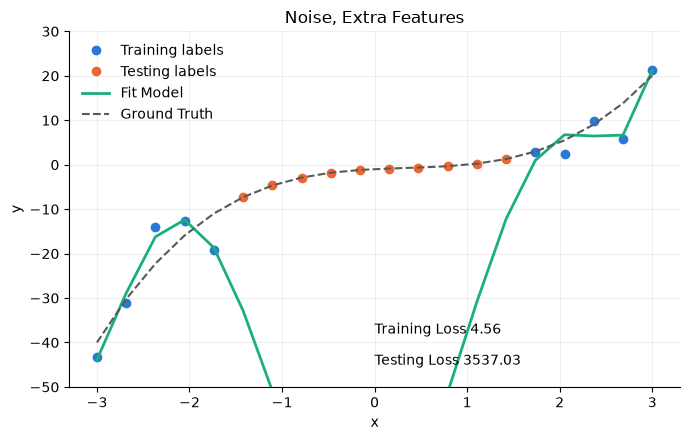

predicción en el test: [-32.8 -50.9 -68.2 -80.7 -85.6 -81.6 -69.4 -51.3 -30.8 -12.2]
verdad en el test:     [-7.3 -4.7 -2.9 -1.8 -1.2 -0.9 -0.6 -0.3  0.2  1.3]


In [13]:
syn_features = np.vstack([syn_x**i for i in range(7)]).T

train_x = syn_features[indices]
test_x = syn_features[test_indices]
test_y = syn_labels[test_indices]

w, *_ = np.linalg.lstsq(train_x, train_y)
print("pesos:", w.round(3))
print("verdad:", np.array([-1, 1, -1, 1, 0, 0, 0]))
resultados_syn["3. ruido, features de más"] = grafica_sintetica(
    w, "Noise, Extra Features", "03_sint_3_extra.png", legend_loc="upper left")
print("predicción en el test:", (test_x @ w).round(1))
print("verdad en el test:    ", test_y.round(1))

**Escenario 3: con ruido y con features de más.** Aquí aparece el overfitting:

| | Escenario 2 (4 features) | Escenario 3 (7 features) |
|---|---|---|
| Loss train | 21.49 | **4.56** |
| Loss test | 1.96 | **3537.03** |

- **En train el modelo "mejora"**: la pérdida baja de 21.49 a 4.56. La curva verde se dobla para
  pasar cerca de cada punto azul, incluidos los que el ruido ha desplazado (en $x = -2.37$ sube hasta
  −16.2, hacia el punto ruidoso de −13.9, cuando la curva verdadera está en −22.3).
- **En test se hunde**: 3537, es decir, casi 1800 veces peor que el escenario 2. En el hueco del
  centro, donde nada la sujeta, la curva cae hasta **−85.6** cuando el valor verdadero es −1.2.
- **Los pesos no se parecen en nada a los verdaderos**: la constante vale −84.7 en vez de −1, y $x^4$,
  $x^5$ y $x^6$ tienen pesos distintos de cero (−7.7, 0.36 y 0.40) aunque en la función real no están.

**Por qué pasa.** Cada feature extra es un grado de libertad más para que la curva se acerque a los
puntos de train. Con 10 features y 10 puntos, la curva podría pasar **exactamente** por los 10 y la
pérdida de train sería 0. Ninguna de esas flexiones responde a la función real: responden al **ruido**
de esos 10 puntos concretos, y entre medias la curva hace lo que le conviene para cuadrar los extremos.

**La lección práctica**: la pérdida de train, sola, lleva a elegir el peor modelo. Si solo miráramos el
train, el escenario 3 (4.56) parecería mejor que el 2 (21.49).

A diferencia de 3.2, aquí **no hay pasos de entrenamiento**: `lstsq` da directamente el mínimo. El
overfitting viene de tener **demasiados parámetros**, no de entrenar demasiado tiempo. Son las dos
causas que da la definición del libro.

#### Escenario 4: ruido y features mal correlacionadas

Ahora las features son $[x^2,\ x,\ e^{-x^2},\ \cos x,\ 1]$. Dos cosas:

- **Falta $x^3$**, el término que domina la curva en los extremos. Con estas features el modelo no
  puede reproducir $f$ exactamente, elija los pesos que elija.
- Entran dos funciones que **no tienen nada que ver** con $f$: $e^{-x^2}$ (una campana centrada en 0)
  y $\cos x$.

Es la situación típica con descriptores moleculares: tenemos features que se relacionan con la label
solo en parte, y otras que no, sin saber de antemano cuáles son cuáles.

Además de la gráfica imprimimos los valores de $e^{-x^2}$ en train y en test; enseguida se verá por qué.

pesos [x^2, x, exp(-x^2), cos x, 1]: [   0.229    7.193 -413.229   30.209   16.033]


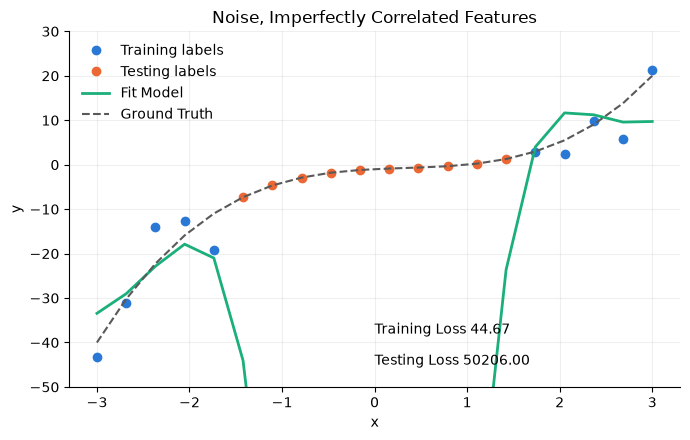

predicción en el test: [ -44.1  -99.9 -189.8 -290.6 -358.3 -356.  -283.8 -178.4  -84.   -23.6]
exp(-x^2) en train: [0.0001 0.0007 0.0037 0.0148 0.049  0.049  0.0148 0.0037 0.0007 0.0001]
exp(-x^2) en test:  [0.133 0.295 0.536 0.799 0.975 0.975 0.799 0.536 0.295 0.133]


In [14]:
syn_features = np.vstack(
    [syn_x**2, syn_x, np.exp(-(syn_x**2)), np.cos(syn_x), np.ones_like(syn_x)]
).T

train_x = syn_features[indices]
test_x = syn_features[test_indices]

w, *_ = np.linalg.lstsq(train_x, train_y)
with np.printoptions(suppress=True):   # sin notación científica
    print("pesos [x^2, x, exp(-x^2), cos x, 1]:", w.round(3))
resultados_syn["4. ruido, features mal correlacionadas"] = grafica_sintetica(
    w, "Noise, Imperfectly Correlated Features", "03_sint_4_imperfectas.png", legend_loc="upper left")
print("predicción en el test:", (test_x @ w).round(1))
print("exp(-x^2) en train:", train_x[:, 2].round(4))
print("exp(-x^2) en test: ", test_x[:, 2].round(3))

**Escenario 4: con ruido y con features mal correlacionadas.** El peor de los cuatro:

- Pérdida de train **44.67**: el modelo no consigue ni acercarse a los datos de train, porque sin
  $x^3$ no puede seguir la curva.
- Pérdida de test **50 206**: en el centro predice hasta **−358** cuando el valor real es −1.2. La
  curva se sale de la gráfica por abajo.

**El culpable es el peso de $e^{-x^2}$: −413.** Basta con mirar los valores de esa feature que se han
impreso:

| | Valores de $e^{-x^2}$ |
|---|---|
| Train ($\lvert x \rvert \ge 1.74$) | entre 0.0001 y 0.049: **casi cero** |
| Test ($\lvert x \rvert \le 1.42$) | entre 0.13 y 0.98 |

En train la campana $e^{-x^2}$ casi no existe, así que ponerle un peso enorme **sale casi gratis**: en
$x = \pm 3$ aporta solo −0.05. En $x = \pm 1.74$ aporta −20, y eso le sirve al modelo para bajar hacia
el punto de −19.2, que el ruido ha dejado 8 unidades por debajo de la curva verdadera. Es decir,
**esa feature se ha usado para aprender ruido.** En test la campana vale casi 1, y el peso de −413 se
aplica entero.

Es lo mismo que le pasó a la **rafinosa** en 3.2: una feature que en train toma valores en un rango
estrecho (como mucho 4 dadores de H) y en test se sale de él (11). El modelo no tiene forma de saber que
un peso que en train "no molestaba" es absurdo fuera de ese rango.

El libro deja abierta la pregunta de si esto es overfitting o simplemente **features mal elegidas**. Los
controles de más abajo permiten separar las dos cosas.

#### Los cuatro escenarios, juntos

In [15]:
print(pd.DataFrame(resultados_syn, index=["loss train", "loss test"]).T.round(2).to_string())

                                        loss train  loss test
1. sin ruido, features perfectas              0.00       0.00
2. ruido, features perfectas                 21.49       1.96
3. ruido, features de más                     4.56    3537.03
4. ruido, features mal correlacionadas       44.67   50206.00


| Escenario | ¿Ruido? | Features | Loss train | Loss test | Diagnóstico |
|---|---|---|---|---|---|
| 1 | no | exactas | 0.00 | 0.00 | perfecto |
| 2 | sí | exactas | 21.49 | 1.96 | train alto por el ruido; el modelo generaliza bien |
| 3 | sí | de más | 4.56 | 3537 | **overfitting**: train mejora, test se dispara |
| 4 | sí | mal correlacionadas | 44.67 | 50 206 | no ajusta bien ni el train **y** además sobreajusta |

Lo más llamativo: **el mejor train (escenario 3) coincide con uno de los peores tests.**

(El valor 50206.00 de la gráfica y el 50205.99 de la tabla siguiente difieren en la última cifra porque
la `loss` de JAX calcula en *float32*, con unos 7 dígitos significativos, y numpy en *float64*, con unos
16. Es un error de redondeo, no una diferencia real.)

#### Variante propia: controles sin ruido

*(No está en el libro.)*

El libro añade el ruido y las features de más **a la vez**, así que no separa cuál de los dos
ingredientes causa el desastre del escenario 3. Como en un experimento de laboratorio, hacen falta los
controles que faltan: **features de más sin ruido** y **features malas sin ruido**.

`sin_ruido_y = syn_labels[indices]` son las labels de train originales, antes de sumarles el ruido.
La función `ajusta` repite el ajuste de arriba para una matriz de features cualquiera y devuelve las dos
pérdidas (aquí con numpy directamente, sin la `loss` de JAX, que es la misma cuenta).

In [16]:
features_syn = {
    "perfectas [x^3, x^2, x, 1]": np.vstack([syn_x**3, syn_x**2, syn_x, np.ones_like(syn_x)]).T,
    "de más [x^0..x^6]": np.vstack([syn_x**i for i in range(7)]).T,
    "mal correlacionadas": np.vstack(
        [syn_x**2, syn_x, np.exp(-(syn_x**2)), np.cos(syn_x), np.ones_like(syn_x)]).T,
}
sin_ruido_y = syn_labels[indices]


def ajusta(F, ytr):
    # Ajusta por mínimos cuadrados con los puntos de train; devuelve pesos, MSE train y MSE test
    wf, *_ = np.linalg.lstsq(F[indices], ytr)
    mse_tr = np.mean((ytr - F[indices] @ wf) ** 2)
    mse_te = np.mean((syn_labels[test_indices] - F[test_indices] @ wf) ** 2)
    return wf, mse_tr, mse_te


filas = []
for nombre, F in features_syn.items():
    for etiqueta, ytr in [("sin ruido", sin_ruido_y), ("con ruido", train_y)]:
        wf, mse_tr, mse_te = ajusta(F, ytr)
        filas.append({"features": nombre, "labels de train": etiqueta,
                      "loss train": mse_tr, "loss test": mse_te, "pesos": np.round(wf, 2)})
controles = pd.DataFrame(filas).set_index(["features", "labels de train"])
print(controles[["loss train", "loss test"]].round(2).to_string())
print()
with np.printoptions(suppress=True):
    for (nombre, etiqueta), fila in controles.iterrows():
        print(f"{nombre:28s} {etiqueta:10s} pesos = {fila['pesos']}")

                                            loss train  loss test
features                   labels de train                       
perfectas [x^3, x^2, x, 1] sin ruido              0.00       0.00
                           con ruido             21.49       1.96
de más [x^0..x^6]          sin ruido              0.00       0.00
                           con ruido              4.56    3537.03
mal correlacionadas        sin ruido             24.54      21.90
                           con ruido             44.67   50205.99

perfectas [x^3, x^2, x, 1]   sin ruido  pesos = [ 1. -1.  1. -1.]
perfectas [x^3, x^2, x, 1]   con ruido  pesos = [ 1.08 -0.96  0.11 -2.24]
de más [x^0..x^6]            sin ruido  pesos = [-1.  1. -1.  1.  0. -0. -0.]
de más [x^0..x^6]            con ruido  pesos = [-84.68  12.67  44.68  -3.4   -7.7    0.35   0.4 ]
mal correlacionadas          sin ruido  pesos = [-1.    7.58 -0.    0.   -1.  ]
mal correlacionadas          con ruido  pesos = [   0.23    7.19 -413.23  

Con los controles, cada ingrediente queda aislado:

| Features | Sin ruido: train / test | Con ruido: train / test |
|---|---|---|
| exactas | 0.00 / 0.00 | 21.49 / 1.96 |
| **de más** | **0.00 / 0.00** | 4.56 / **3537** |
| **mal correlacionadas** | **24.54 / 21.90** | 44.67 / **50 206** |

**1. Las features de más, sin ruido, no hacen ningún daño.** Los pesos salen exactamente
$[-1, 1, -1, 1, 0, 0, 0]$: `lstsq` pone a cero las features que sobran, porque no hay nada que ganar
con ellas. Las features extra solo son peligrosas **cuando hay ruido que aprender**. El overfitting
necesita los dos ingredientes a la vez: **ruido** + **flexibilidad** para seguirlo.

**2. Las features mal correlacionadas, sin ruido, dan un error moderado y parecido en train y en
test (24.5 y 21.9).** Esto no es overfitting, es lo contrario: el modelo **no es capaz de representar**
$f$. Los pesos de $e^{-x^2}$ y $\cos x$ salen 0, y el de $x$ sube a 7.58 para imitar como puede al
$x^3$ que falta. Este tipo de error se llama **underfitting** (subajuste) o **sesgo**: el modelo es
demasiado limitado, y se reconoce porque **train y test fallan por igual**. Lo veremos a fondo en 3.4.

**3. Con ruido, esas mismas features malas se disparan hasta 50 206.** Ahora sí hay overfitting, además
del sesgo: el ruido le da al modelo algo que perseguir, y $e^{-x^2}$ le da una forma barata de hacerlo.

La respuesta a la duda del libro es, por tanto, que **son las dos cosas**. Unos ~22 de pérdida de test
se deben a haber elegido mal las features (error que aparecería aunque no hubiera ruido); el resto,
hasta 50 206, es overfitting.

#### Variante propia: ¿y con otro ruido?

*(No está en el libro.)*

Todo lo anterior usa **un** sorteo de ruido (semilla 4). Con solo 10 puntos de train, otro sorteo
puede cambiar mucho los números. Repetimos los tres escenarios con ruido para las semillas 0 a 9.

En la gráfica, cada columna es un escenario y cada punto una semilla; las líneas grises unen los puntos
de la misma semilla. El eje Y es **logarítmico** (cada marca multiplica por 10), porque las pérdidas
van de menos de 1 a cientos de miles.

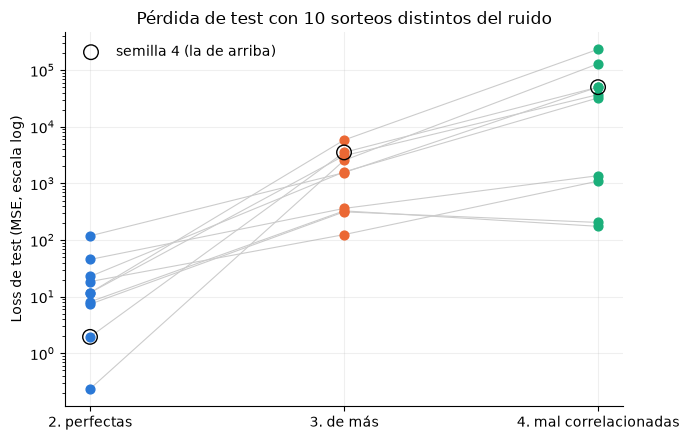

        2. perfectas        3. de más         4. mal correlacionadas          
               train   test     train    test                  train      test
semilla                                                                       
0                5.6   22.8       0.6  1599.3                    8.1   32416.4
1                9.4    0.2       4.1  2553.1                   24.3  129795.3
2               25.3   11.8      10.0  5848.2                   22.6  233787.6
3               45.0  118.8      17.2  1554.9                   70.4   50447.5
4               21.5    2.0       4.6  3537.0                   44.7   50206.0
5                6.1    7.4       1.6   315.6                   71.0     205.0
6               27.8   11.8      18.4  3087.6                   29.5   37061.2
7                8.7    8.1       4.8   328.5                   20.9     175.1
8                7.7   45.5       6.3   362.6                   43.5    1372.6
9               11.1   18.5       8.1   124.9       

In [17]:
escenarios_ruido = {
    "2. perfectas": features_syn["perfectas [x^3, x^2, x, 1]"],
    "3. de más": features_syn["de más [x^0..x^6]"],
    "4. mal correlacionadas": features_syn["mal correlacionadas"],
}
filas = []
for s in range(10):
    ytr = syn_labels[indices] + np.random.default_rng(s).normal(scale=5, size=len(indices))
    fila = {"semilla": s}
    for nombre, F in escenarios_ruido.items():
        _, mse_tr, mse_te = ajusta(F, ytr)
        fila[(nombre, "train")] = mse_tr
        fila[(nombre, "test")] = mse_te
    filas.append(fila)
semillas_syn = pd.DataFrame(filas).set_index("semilla")
semillas_syn.columns = pd.MultiIndex.from_tuples(semillas_syn.columns)

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = ["#2a78d6", "#eb6834", "#1baf7a"]
nombres = list(escenarios_ruido)
tests = semillas_syn.xs("test", axis=1, level=1)[nombres].values
for fila in tests:
    ax.plot(range(3), fila, color="0.8", linewidth=0.8, zorder=1)
for j, (nombre, color) in enumerate(zip(nombres, colores)):
    ax.scatter(np.full(10, j), tests[:, j], color=color, s=40, zorder=2)
    ax.scatter([j], [tests[4, j]], facecolor="none", edgecolor="black", s=110, zorder=3,
               label="semilla 4 (la de arriba)" if j == 0 else None)
ax.set_yscale("log")
ax.set_xticks(range(3), nombres)
ax.set_ylabel("Loss de test (MSE, escala log)")
ax.set_title("Pérdida de test con 10 sorteos distintos del ruido")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.2)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/03_sint_semillas.png", dpi=150)
plt.show()

print(semillas_syn.round(1).to_string())
print()
print("¿test de 'de más' > test de 'perfectas'?:",
      (semillas_syn[("3. de más", "test")] > semillas_syn[("2. perfectas", "test")]).sum(), "de 10")
print("¿test de 'perfectas' > su train?:",
      (semillas_syn[("2. perfectas", "test")] > semillas_syn[("2. perfectas", "train")]).sum(), "de 10")

Qué cambia y qué no con otros sorteos del ruido:

**Lo que se mantiene (la conclusión del libro):**
- **Las features de más empeoran el test en las 10 semillas**, y nunca por poco: como mínimo, 6.7
  veces peor que con las features exactas. El test del escenario 3 va de 125 a 5848.
- **El escenario 4 es el peor en 8 de 10 semillas.** En las semillas 5 y 7 queda por debajo del 3
  (205 y 175 frente a 316 y 329), pero sigue muy lejos del escenario 2.

**Lo que depende mucho del sorteo:**
- **El escenario 2 va de 0.24 a 118.8 en test.** Con la semilla 4 nos tocó un valor bajo (1.96). La
  mediana de las 10 es 11.8. El ruido desplaza los pesos, y con 10 puntos a veces los desplaza bastante
  (semilla 3: 118.8). Aun así, siempre queda muy por debajo de su escenario 3.
- **Que el test del escenario 2 salga por debajo del train** (como en la semilla 4) ocurre en 5 de 10
  semillas: no es una regla. La idea que sí se mantiene es que la pérdida de train con ruido no puede
  bajar mucho de la varianza del ruido.
- **Los valores exactos del escenario 4 van de 175 a 233 788**: más de tres órdenes de magnitud. Cuando
  un modelo sobreajusta con pesos enormes, el tamaño del desastre depende mucho de qué ruido le haya
  tocado.

Un detalle numérico: la pérdida media de train es **16.8** con las features exactas y **7.6** con las
de más, las dos por debajo de la varianza del ruido (25). Cada parámetro "absorbe" una parte del ruido
de train, y cuantos más parámetros hay, más absorben. Esa parte absorbida es justo la que no se
repite en test.

---

### 3.2.2 Conclusión del overfitting

El libro cierra la sección 3.2 con cuatro ideas. Aquí van con los números que las respaldan en este
notebook:

1. **En datos reales el overfitting es inevitable en algún grado**, porque siempre hay ruido y las
   features nunca son perfectas. Con los datos sintéticos lo hemos podido apagar (escenario 1), pero en
   la solubilidad no hay forma de hacerlo.
2. **Separar train y test es la forma de medir si el modelo generaliza**: simula usarlo con moléculas
   que no ha visto nunca. Sin el test, el escenario 3 (train 4.56) habría parecido mejor que el 2
   (train 21.49).
3. **Tener más features de las necesarias, o features que se relacionan mal con la label, hace más
   probable el overfitting.** Con ruido, las 3 features que sobraban multiplicaron la pérdida de test
   por ~1800 (de 1.96 a 3537), y las mal correlacionadas por ~25 000 (hasta 50 206).
4. **Señal de alarma: la pérdida de train baja mientras la de test sube.** En 3.2 lo vimos a lo largo
   de los pasos de entrenamiento; en 3.2.1, al pasar de 4 a 7 features.

Y dos matices propios, que salen de los controles y de las semillas:

- **El overfitting necesita ruido y flexibilidad a la vez.** Las features de más sin ruido son
  inofensivas; el ruido con las features justas, también.
- **No todo error de test es overfitting.** Si el modelo falla por igual en train y en test (features
  malas sin ruido: 24.5 y 21.9), lo que ocurre es que es demasiado limitado: *underfitting* o sesgo.

### Resumen de 3.2.1 y 3.2.2

- **Los datos sintéticos permiten controlar** $f$ y el ruido. Con $f(x) = x^3 - x^2 + x - 1$, un modelo
  lineal con features $[x^3, x^2, x, 1]$ puede ser exacto.
- **`np.linalg.lstsq`** da el mínimo exacto del MSE sin descenso de gradiente. Por eso aquí el
  overfitting solo puede venir de las features, no de entrenar demasiados pasos.
- **Train en los extremos y test en el centro**: el modelo tiene que rellenar un hueco sin datos.
- **Pérdidas de test** con la semilla 4: 0.00 (sin ruido) → 1.96 (ruido) → **3537** (ruido y features de
  más) → **50 206** (ruido y features mal correlacionadas).
- **Pérdida de train más baja ≠ mejor modelo**: el escenario 3 tiene el train más bajo de los tres con
  ruido.
- **Los pesos enormes delatan el overfitting**: −84.7 en la constante del escenario 3, −413 en la
  campana del 4. Esa campana casi valía cero en train, igual que le pasó a la rafinosa con sus
  dadores de H en 3.2.
- *Variante propia*: el overfitting necesita **ruido y flexibilidad** a la vez. Un error parecido en
  train y en test es **underfitting**, no overfitting.
- *Variante propia*: en 10 semillas, las features de más empeoran el test siempre (entre 6.7 y 10 850
  veces). Los valores concretos varían en órdenes de magnitud.

**Siguiente**: 3.3, *Exploring Effect of Feature Number*. En vez de comparar 4 y 7 features, el libro va
añadiendo features una a una y mide cómo cambian las pérdidas de train y de test.

---

## 3.3 Efecto del número de features

### El planteamiento

En 3.2.1 vimos que el overfitting depende de **cuántas** features hay y de **cuáles**. Elegir las features
es una de las decisiones más importantes del aprendizaje supervisado, y en química el menú es casi
infinito:

- Nuestro dataset trae **17 descriptores**, pero son una mínima parte de los posibles. El programa
  **Dragon** calcula más de 5000; RDKit, unos 200.
- Se pueden combinar descriptores entre sí, pasarlos por funciones, o añadir datos experimentales, de
  simulación o de cálculos cuánticos.

**Descriptor** es la palabra de química y materiales para *feature*. Es más antigua y viene del
**QSAR** (*quantitative structure–activity relationship*), con una larga historia en diseño de
fármacos. En este libro las dos palabras significan lo mismo.

La pregunta de la sección: **¿qué pasa con las pérdidas de train y de test a medida que aumenta el
número de features?**

### Aviso: el código del libro está oculto, y no hace exactamente lo que dice el texto

En la web, esta sección solo trae texto y dos figuras; el libro dice que el código es complejo y lo
omite. Está en el notebook del libro en GitHub, en celdas marcadas como `remove-cell` (ocultas al
publicar). Lo hemos recuperado de ahí y lo reproducimos abajo. Al leerlo aparecen **tres diferencias**
con lo que cuenta el texto:

1. **Las features "nuevas" no son descriptores nuevos.** Para tener $f$ features, el libro multiplica los
   17 descriptores por una matriz aleatoria. Salen $f$ **combinaciones lineales** de los mismos 17
   descriptores (lo explicamos en detalle abajo). A partir de cierto número, añadir features no añade
   información.
2. **El ajuste es `lstsq`**, el mínimo exacto de 3.2.1, sin pasos de entrenamiento. El texto habla de
   que a partir de ~30 features "el modelo ya no converge", pero aquí no hay nada que converger. En el
   código hay una función `adam_fit` con descenso de gradiente, pero **no se llega a usar**: es
   probable que el texto se escribiera para una versión anterior del código.
3. **La segunda figura usa 500 moléculas de train, no 250** como dice el texto.

Por eso las cifras que describe el texto del libro no tienen por qué coincidir con las nuestras. Lo
comprobaremos, y después haremos un experimento propio que sí pone a prueba lo que el texto afirma.

### El experimento del libro, paso a paso

**1. Diez repartos de datos.** Con 25 moléculas el resultado depende mucho del sorteo (lo vimos en 3.2),
así que el libro repite todo **K = 10 veces** y promedia.

| Array | Forma | Qué contiene |
|---|---|---|
| `train_data[0]` | (10, 25, 17) | 10 repartos × 25 moléculas × 17 descriptores |
| `train_data[1]` | (10, 25) | sus solubilidades |
| `test_data[0]`, `test_data[1]` | igual | otras 25 moléculas por reparto |

Es un tensor de rango 3, como los del capítulo 1: la primera dimensión es el número de reparto.

Dos detalles del código del libro que conviene saber:
- **Las features no se estandarizan.** Se usan los descriptores en crudo. Con `lstsq` no importa para
  el mínimo (a diferencia del descenso de gradiente de 2.3.8), pero sí para el redondeo numérico.
- **Train y test se sortean por separado**, cada uno con su `sample`, así que una misma molécula puede
  caer en los dos. Con 25 de casi 10 000 es raro; lo contamos.

Nuestras diferencias: semilla fija (`np.random.default_rng(4)`, que se le pasa a `sample` como
`random_state`) en lugar del azar sin semilla del libro.

In [18]:
# get K samples of N data points
rng_33 = np.random.default_rng(4)
N = 25
K = 10
train_data = [np.empty((K, N, len(feature_names))), np.empty((K, N))]
test_data = [np.empty((K, N, len(feature_names))), np.empty((K, N))]

repetidas = []
for i in range(K):
    sample = soldata.sample(N, replace=False, random_state=rng_33)
    train_data[0][i] = sample[feature_names].values
    train_data[1][i] = sample["Solubility"].values
    sample_test = soldata.sample(N, replace=False, random_state=rng_33)
    test_data[0][i] = sample_test[feature_names].values
    test_data[1][i] = sample_test["Solubility"].values
    repetidas.append(len(set(sample.index) & set(sample_test.index)))

print("forma de train_data[0]:", train_data[0].shape)
print("moléculas repetidas entre train y test, por reparto:", repetidas)

forma de train_data[0]: (10, 25, 17)
moléculas repetidas entre train y test, por reparto: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


**2. Cómo fabricar $f$ features a partir de 17.** Cada reparto recibe una matriz aleatoria
`ftransform` de forma $(17, f)$, con números sacados de una normal. Las nuevas features son

$$X_{\text{nuevo}} = X \cdot F \qquad (25 \times 17) \cdot (17 \times f) = (25 \times f)$$

Cada columna nueva es una **suma ponderada de los 17 descriptores**, con pesos al azar; por ejemplo,
$0.3\cdot\text{MolWt} - 1.2\cdot\text{MolLogP} + \dots$. Así se puede pedir cualquier número de
features: 3, 17 o 45.

**3. La función `fit`.** Recibe la matriz `ftransform`, los datos de train y los de test, y:
1. transforma las features con `jnp.dot(x, ftransform)`;
2. ajusta los pesos con `lstsq` (aquí la versión de JAX, `jnp.linalg.lstsq`; hace lo mismo que la de
   numpy);
3. calcula el bias aparte, como la media de lo que el ajuste deja sin explicar:
   `b = mean(y - x·w)`. Como la matriz no lleva columna de unos, el bias no entra en `lstsq`;
4. devuelve las pérdidas (MSE) de test y de train, con la `loss` de 3.2.

El argumento `rng` no se usa; el libro lo deja porque lo usaba la función `adam_fit`, que omitimos
porque ninguna celda la llama.

**4. `jax.vmap`: la misma función para los 10 repartos a la vez.** `vmap` (*vectorizing map*) convierte
una función escrita para **un** reparto en otra que acepta **una pila** de repartos y los procesa en
paralelo, sin bucle `for`.

El segundo argumento, `(0, 0, 0, 0, 0, None)`, dice por qué eje recorrer cada argumento: `0` = "el
primer eje es el número de reparto" (para `ftransform`, `x`, `y`, `test_x` y `test_y`), y `None` = "este
argumento es el mismo para todos" (`rng`).

In [19]:
def fit(ftransform, x, y, test_x, test_y, rng=None):
    x = jnp.dot(x, ftransform)
    test_x = jnp.dot(test_x, ftransform)
    w, *_ = jax.numpy.linalg.lstsq(x, y)
    b = jnp.mean(y - jnp.dot(x, w))
    return loss(w, b, test_x, test_y), loss(w, b, x, y)


vfit = jax.vmap(fit, (0, 0, 0, 0, 0, None))

**5. El barrido.** Se prueba cada número de features de 1 a 24, y después 25, 30, 35, 40 y 45.

Para poder apilar matrices de distinto tamaño, todas se crean con el tamaño máximo (17 × 45) y se
rellenan con ceros las columnas que sobran. Una columna de ceros da una feature que vale 0 en todas las
moléculas: no aporta nada, así que "17 × 45 con solo 10 columnas no nulas" equivale a 10 features.

`fts` tiene forma (29, 10, 17, 45): 29 tamaños × 10 repartos × la matriz de cada uno.

Para cada tamaño, `vfit` devuelve un array (2, 10), con las pérdidas de test y de train de cada reparto,
y `np.mean(..., axis=1)` promedia sobre los 10 repartos.

En la gráfica, la línea vertical marca **N = 25**, el número de moléculas de train.

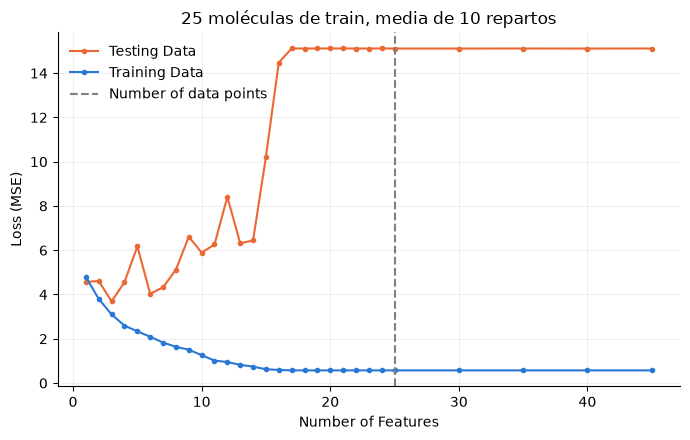

features      1     2     3     4     5     6     7     8     9     10    11    12    13    14     15     16     17     18     19     20     21     22     23     24     25     30     35     40     45
loss test   4.57  4.61  3.69  4.56  6.18  4.03  4.33  5.12  6.61  5.89  6.26  8.41  6.31  6.44  10.22  14.48  15.11  15.11  15.11  15.11  15.12  15.11  15.11  15.11  15.11  15.11  15.11  15.11  15.11
loss train  4.79  3.80  3.10  2.59  2.34  2.09  1.83  1.63  1.51  1.26  1.01  0.95  0.82  0.74   0.62   0.59   0.57   0.57   0.57   0.57   0.57   0.57   0.57   0.57   0.57   0.57   0.57   0.57   0.57


In [20]:
feature_sizes = list(range(1, N)) + list(range(N, 2 * N, 5))
max_features = max(feature_sizes)
fts = np.zeros((len(feature_sizes), K, len(feature_names), max_features))
for i, f in enumerate(feature_sizes):
    fts[i, :, :, :f] = rng_33.normal(size=(K, len(feature_names), f))

losses = []
for i, f in enumerate(feature_sizes):
    l = np.mean(vfit(fts[i], *train_data, *test_data, None), axis=1)
    losses.append(l)
losses = np.array(losses)   # columnas: test, train


def grafica_nfeatures(losses, n_train, archivo):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(feature_sizes, losses[:, 0], "o-", color="#eb6834", markersize=3, label="Testing Data")
    ax.plot(feature_sizes, losses[:, 1], "o-", color="#2a78d6", markersize=3, label="Training Data")
    if n_train <= max(feature_sizes):
        ax.axvline(n_train, linestyle="--", color="0.5", label="Number of data points")
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title(f"{n_train} moléculas de train, media de {K} repartos")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    fig.tight_layout()
    fig.savefig(f"../figuras/{archivo}", dpi=150)
    plt.show()


grafica_nfeatures(losses, N, "03_nfeatures_25.png")
tabla_25 = pd.DataFrame(losses, index=feature_sizes, columns=["loss test", "loss train"])
tabla_25.index.name = "features"
print(tabla_25.T.round(2).to_string())

**Cómo se lee la gráfica** (25 moléculas de train, media de 10 repartos):

| Features | Loss train | Loss test | Qué pasa |
|---|---|---|---|
| 1 | 4.79 | 4.57 | casi como predecir la media (varianza ≈ 5.6) |
| **3** | 3.10 | **3.69** | el mejor test de toda la curva |
| 4–14 | 2.59 → 0.74 | entre 4.0 y 8.4, en dientes de sierra | el train mejora sin parar; el test no, y tiende a subir |
| 15–16 | 0.62 → 0.59 | 10.22 → 14.48 | el test se dispara |
| **17 a 45** | **0.57** | **15.11** | **las dos curvas se quedan planas, exactamente en el mismo valor** |

Comparado con lo que describe el texto del libro:

- ✔ **Underfit al principio**: con 1–3 features, train y test son parecidos y los dos mejoran al añadir
  features.
- ✔ **Después, overfitting ligero**: el train sigue bajando y el test deja de mejorar.
- ≈ **Un salto grande**: el libro lo sitúa en unas 10 features; aquí llega entre 15 y 17.
- ✘ **"A partir de ~30 features el train sube porque no converge"**: aquí no pasa. Con `lstsq` no hay
  convergencia posible, y la curva es completamente plana.
- ✔ **Nada especial al cruzar las 25 features** (la línea discontinua). Lo dice el propio pie de figura
  del libro, y aquí se ve igual.

**Lo sospechoso es la meseta:** de 17 a 45 features, las pérdidas no cambian ni en el segundo decimal.
Dar al modelo 45 features en vez de 17 no cambia absolutamente nada. Lo explicamos dos celdas más abajo.

Las diez muestras apenas se solapan: solo un reparto comparte una molécula entre train y test.

### Lo mismo con 500 moléculas

El libro repite el experimento con más datos. El texto habla de 250 moléculas de train y 250 de test,
pero el código usa **`N2 = 500`** para cada conjunto; seguimos el código.

Se sortean matrices `fts` nuevas y 10 repartos nuevos, y se reutiliza `vfit` sin cambios: `vmap` no
necesita saber cuántas moléculas hay.

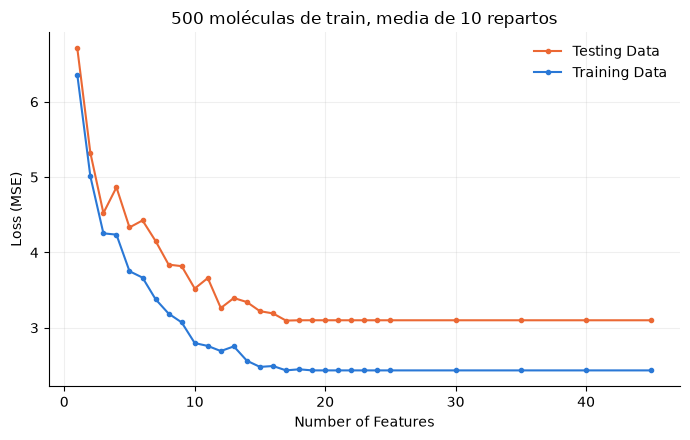

features      1     2     3     4     5     6     7     8     9     10    11    12    13    14    15    16    17    18    19    20    21    22    23    24    25    30    35    40    45
loss test   6.71  5.32  4.52  4.86  4.33  4.43  4.15  3.84  3.82  3.52  3.66  3.26  3.40  3.34  3.22  3.19  3.10  3.10  3.10  3.10  3.10  3.10  3.10  3.10  3.10  3.10  3.10  3.10  3.10
loss train  6.36  5.01  4.25  4.24  3.75  3.67  3.38  3.19  3.07  2.80  2.76  2.69  2.75  2.56  2.48  2.49  2.44  2.45  2.44  2.43  2.43  2.43  2.43  2.43  2.43  2.43  2.43  2.43  2.43

moléculas repetidas entre train y test, por reparto: [25, 32, 25, 18, 17, 29, 21, 26, 19, 30]


In [21]:
# get K samples of N data points
N2 = 500
K = 10

fts = np.zeros((len(feature_sizes), K, len(feature_names), max_features))
for i, f in enumerate(feature_sizes):
    fts[i, :, :, :f] = rng_33.normal(size=(K, len(feature_names), f))

train_data = [np.empty((K, N2, len(feature_names))), np.empty((K, N2))]
test_data = [np.empty((K, N2, len(feature_names))), np.empty((K, N2))]

repetidas = []
for i in range(K):
    sample = soldata.sample(N2, replace=False, random_state=rng_33)
    train_data[0][i] = sample[feature_names].values
    train_data[1][i] = sample["Solubility"].values
    sample_test = soldata.sample(N2, replace=False, random_state=rng_33)
    test_data[0][i] = sample_test[feature_names].values
    test_data[1][i] = sample_test["Solubility"].values
    repetidas.append(len(set(sample.index) & set(sample_test.index)))

losses_500 = []
for i, f in enumerate(feature_sizes):
    l = np.mean(vfit(fts[i], *train_data, *test_data, None), axis=1)
    losses_500.append(l)
losses_500 = np.array(losses_500)

grafica_nfeatures(losses_500, N2, "03_nfeatures_500.png")
tabla_500 = pd.DataFrame(losses_500, index=feature_sizes, columns=["loss test", "loss train"])
tabla_500.index.name = "features"
print(tabla_500.T.round(2).to_string())
print("\nmoléculas repetidas entre train y test, por reparto:", repetidas)

Con 20 veces más datos, la historia cambia:

| Features | Loss train | Loss test |
|---|---|---|
| 1 | 6.36 | 6.71 |
| 10 | 2.80 | 3.52 |
| **17 a 45** | **2.43** | **3.10** |

- **No hay overfitting visible.** El test baja casi a la vez que el train, y la distancia entre los dos
  al final es pequeña (3.10 frente a 2.43). Con 25 moléculas era enorme (15.11 frente a 0.57).
- **El test final es mucho mejor**: 3.10 frente a 15.11 con 25 moléculas. En RMSE, 1.76 unidades de
  log S.
- **Underfit hasta unas 10–15 features** y después cada feature aporta muy poco, como dice el libro.
- **Y la misma meseta desde 17**, de nuevo exacta. Tampoco aquí aparece el underfitting "por mal
  entrenamiento" a partir de 20 features que describe el texto.

**Moléculas repetidas:** con 500 moléculas sorteadas dos veces de unas 10 000, entre 17 y 32 moléculas
por reparto están a la vez en train y en test (un 3–6 % del test). Esas moléculas el modelo ya las ha
visto, así que el test sale un poco más optimista de la cuenta. Es un defecto menor del código del
libro; en nuestra variante lo evitamos.

### ¿Por qué se aplanan las curvas?

**El rango de una matriz** es el número de columnas que aportan información de verdad: las que no se
pueden escribir como combinación de las otras. Un ejemplo químico: si tuviéramos las columnas
"nº de C", "nº de H" y "nº de C + nº de H", la tercera no añade nada. La matriz tendría 3 columnas pero
**rango 2**.

`np.linalg.matrix_rank` calcula ese número. Vamos a mirar dos cosas:

1. El rango de los 17 descriptores del dataset completo.
2. El rango de las features del libro, $X \cdot F$, para varios valores de $f$, en un reparto de 25
   moléculas.

In [22]:
X_todo = soldata[feature_names].values
print("rango de los 17 descriptores (9982 moléculas):", np.linalg.matrix_rank(X_todo))

# ¿qué combinación exacta sobra?
anillos = soldata["NumAromaticRings"] + soldata["NumAliphaticRings"]
print("máx |RingCount - (NumAromaticRings + NumAliphaticRings)|:",
      (soldata["RingCount"] - anillos).abs().max())
print("NumSaturatedRings <= NumAliphaticRings en todas:",
      bool((soldata["NumSaturatedRings"] <= soldata["NumAliphaticRings"]).all()))

X25 = soldata.sample(25, random_state=4)[feature_names].values
print()
for f in [5, 10, 15, 16, 17, 20, 30, 45]:
    F = rng_33.normal(size=(17, f))
    print(f"f = {f:2d}  ->  X·F tiene forma {(X25 @ F).shape} y rango {np.linalg.matrix_rank(X25 @ F)}")

rango de los 17 descriptores (9982 moléculas): 16
máx |RingCount - (NumAromaticRings + NumAliphaticRings)|: 0.0
NumSaturatedRings <= NumAliphaticRings en todas: True

f =  5  ->  X·F tiene forma (25, 5) y rango 5
f = 10  ->  X·F tiene forma (25, 10) y rango 10
f = 15  ->  X·F tiene forma (25, 15) y rango 15
f = 16  ->  X·F tiene forma (25, 16) y rango 16
f = 17  ->  X·F tiene forma (25, 17) y rango 16
f = 20  ->  X·F tiene forma (25, 20) y rango 16
f = 30  ->  X·F tiene forma (25, 30) y rango 16
f = 45  ->  X·F tiene forma (25, 45) y rango 16


**Los 17 descriptores solo tienen rango 16.** Uno sobra, y es química pura:

$$\texttt{RingCount} = \texttt{NumAromaticRings} + \texttt{NumAliphaticRings}$$

en las 9982 moléculas sin excepción: todo anillo es aromático o alifático. (`NumSaturatedRings` no
añade otra dependencia: es un subconjunto de los alifáticos, pero no una suma exacta de otras
columnas.)

**Y las features del libro nunca pasan de rango 16.** $X \cdot F$ puede tener 17, 30 o 45 columnas, pero
cada una es una mezcla de los mismos 16 ingredientes independientes. Es como tener 45 disoluciones
preparadas mezclando las mismas 16 sustancias madre: no contienen nada que no estuviera en las madres.

**Por qué eso deja las curvas exactamente planas:** a partir de 16 features, $X \cdot F$ contiene
exactamente la misma información que $X$. El mejor ajuste por mínimos cuadrados es el mismo y las
predicciones son idénticas, así que las pérdidas también lo son. Por eso la meseta empieza en 16–17.
En una prueba aparte con numpy en *float64*, empieza ya en 16; el *float32* de JAX necesita una más
por redondeo.

**Consecuencias:**
- **El experimento del libro no puede decir nada de lo que pasa al cruzar $f = N = 25$**: el modelo
  nunca tiene más de 16 features efectivas + el bias = **17 parámetros**. Por eso el pie de figura del
  libro no ve "ningún cambio significativo" al cruzar los 25 datos.
- **El gran salto del test entre 15 y 17 features sí es real**: es el modelo con 17 parámetros para 25
  moléculas, muy parecido al de 3.2 (allí teníamos 18 parámetros nominales, 17 efectivos).
- **Relación con el capítulo 2:** allí vimos la multicolinealidad aproximada. Aquí hay una dependencia
  **exacta**. `lstsq` la maneja sin problemas, pero conviene saberlo.

### Lo que concluye el libro

El libro cierra la sección con estas ideas (en nuestras palabras):

1. **Añadir features ayuda hasta cierto punto.** Al principio el modelo está *underfit* (le faltan
   features) y mejora al añadirlas; después deja de mejorar.
2. **El overfitting empieza cuando el número de features se acerca al número de datos.** Algunos métodos
   se vuelven inestables justo cuando los dos números coinciden.
3. **Con muchísimas features el overfitting puede desaparecer**, por el tamaño y la complejidad del
   modelo. Pero también aparece el riesgo de underfitting.
4. **Con más datos, menos riesgo de overfitting**: el ruido pesa menos frente a la señal. El libro añade
   una regla práctica basada en el teorema central del límite: el ruido de una media baja con
   $1/\sqrt{N}$, así que reducirlo 10 veces exige 100 veces más datos. Por eso, **para duplicar el número
   de features conviene cuadruplicar los datos**, y suele salir más a cuenta elegir mejor las features.

Las ideas 2 y 3 hablan de lo que pasa **al cruzar** $f = N$. Pero el experimento del libro no puede
enseñarlo: con 25 moléculas, más allá de 16 features no entra información nueva. Para ponerlas a prueba
necesitamos features de verdad distintas.

### Variante propia: ~200 descriptores reales de RDKit

*(No está en el libro.)*

RDKit trae una función, `Descriptors.CalcMolDescriptors(mol)`, que calcula de golpe **todos** sus
descriptores (217 en nuestra versión de RDKit; el número cambia entre versiones) y los devuelve en un
diccionario `{nombre: valor}`. Incluye los 17 del dataset y muchos más: índices topológicos, áreas por
tipo de átomo, contadores de grupos funcionales (`fr_...`), etc.

Calcularlos para las 9982 moléculas tarda unos 35 segundos. Siguiendo la regla del proyecto de no
repetir trabajo caro, la celda los **guarda en `data/rdkit_descriptores.csv`** la primera vez y, en las
siguientes ejecuciones, los lee de ahí (`os.path.exists` comprueba si el archivo ya está).

Limpieza:
- **Descriptores que fallan a menudo, fuera**: si un descriptor da un valor no finito (`NaN` o
  infinito) en más del 1 % de las moléculas, se quita la columna. Así no perdemos cientos de moléculas
  por culpa de un solo descriptor.
- **Moléculas**: después se quitan las pocas que RDKit no puede leer o que aún tienen algún valor no
  finito.
- **`Ipc` fuera**: es un índice de teoría de la información que crece de forma explosiva con el tamaño
  de la molécula. En este dataset llega a valores del orden de $10^{158}$, que rompen cualquier cuenta.

`RDLogger.DisableLog` silencia los avisos que RDKit imprime al leer algunas moléculas.

In [23]:
import os
from rdkit import RDLogger
from rdkit.Chem import Descriptors

RDLogger.DisableLog("rdApp.*")
ruta_desc = "../data/rdkit_descriptores.csv"
if os.path.exists(ruta_desc):
    desc = pd.read_csv(ruta_desc)
else:
    filas_desc = []
    for smi in soldata["SMILES"]:
        mol = rdkit.Chem.MolFromSmiles(smi)
        filas_desc.append(Descriptors.CalcMolDescriptors(mol) if mol is not None else {})
    desc = pd.DataFrame(filas_desc, index=soldata.index)
    desc.to_csv(ruta_desc, index=False)

print("descriptores calculados:", desc.shape[1], f"(RDKit {rdkit.__version__})")
print("valor máximo de Ipc:", f"{desc['Ipc'].max():.2e}")

desc = desc.drop(columns=["Ipc"]).astype(float)
no_finitos = (~np.isfinite(desc)).sum()
print("\ndescriptores con algún valor no finito:")
print(no_finitos[no_finitos > 0].value_counts().rename("nº de descriptores").rename_axis("moléculas afectadas").to_string())
print("los que fallan en más del 1 %:", list(no_finitos[no_finitos > 0.01 * len(desc)].index))
desc = desc.loc[:, no_finitos <= 0.01 * len(desc)]
validas = np.isfinite(desc.values).all(axis=1)
X_rd = desc.values[validas]
y_rd = soldata["Solubility"].values[validas]
print(f"moléculas válidas: {validas.sum()} de {len(soldata)}")
print("matriz de features:", X_rd.shape)

descriptores calculados: 217 (RDKit 2026.03.6)
valor máximo de Ipc: 2.20e+158

descriptores con algún valor no finito:
moléculas afectadas
2      204
886      8
104      2
103      2
los que fallan en más del 1 %: ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']
moléculas válidas: 9980 de 9982
matriz de features: (9980, 204)


#### El montaje

Para cada reparto:

1. Se sortean $2N$ moléculas distintas: las $N$ primeras son el train y las $N$ siguientes el test (sin
   repetidas, a diferencia del libro).
2. **Se quitan los descriptores constantes en ese train.** Con 25 moléculas, muchos contadores de
   grupos funcionales raros valen 0 en todas; no aportan nada y además no se pueden estandarizar
   (desviación 0).
3. **Se estandariza** con la media y la desviación del train, como en 3.2.
4. **Se barajan los descriptores** (`rng.permutation`) y se van tomando los $f$ primeros. Así, en cada
   reparto las features entran en un orden distinto y ninguna conclusión depende de un orden concreto.
5. Se ajusta con `np.linalg.lstsq`, añadiendo una **columna de unos** para el bias. Con $f$ features hay
   por tanto $f + 1$ parámetros.

**¿Qué hace `lstsq` cuando hay más parámetros que datos?** Hay infinitas combinaciones de pesos que
ajustan el train perfectamente. `lstsq` elige, entre todas, **la de pesos más pequeños**, la de menor
**norma** $\lVert w \rVert = \sqrt{w_1^2 + w_2^2 + \dots}$. Guardamos esa norma para cada ajuste.

**Mediana en vez de media.** Con 100 repartos, basta con uno catastrófico (un test con una molécula
rarísima que dispara el error a millones) para arrastrar la media. La **mediana**, el valor que deja la
mitad de los repartos por debajo, no se deja arrastrar. La banda sombreada va del **percentil 25 al
75**: la mitad central de los repartos. Así se ven a la vez el valor típico y su dispersión.

Hacemos 100 repartos con 25 moléculas y 30 con 250 (estos son más lentos). El eje Y es logarítmico.

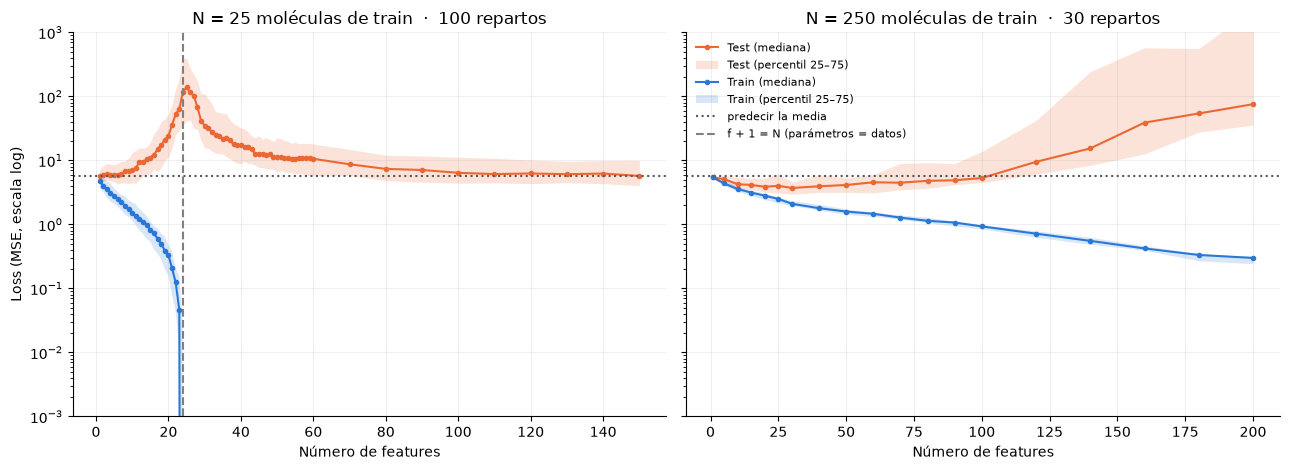

varianza de la solubilidad (MSE de predecir la media): 5.61

N = 25
features             1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17      18       19       20      21       22       23       24       25       26       27       28       29   30   31   32   33   34   35      36       37       38       39       40       41       42       43       44      45       46       47       48       49       50       51       52       53       54       55       56       57       58       59       60       70       80       90       100      110     120      130      140      150
test mediana        5.79  5.9  6.1 5.82 5.92 5.99 6.17 6.72 6.95 6.96 7.52 9.49 9.48 10.5 11.1 12.3 14.9    17.2     21.1     24.1    35.9     52.7     63.6      118      138      116      102     68.1     41.8 34.6 32.2 27.5 24.7 23.7 21.4    22.3     20.5     17.8     17.2     17.3     16.4       16     14.9     12.7    12.7     12.8     12.3     12.5     11.5     11.2     11.1      

In [24]:
def experimento_rdkit(n_train, tamanos, n_repartos, seed=4):
    # Devuelve un array (n_repartos, len(tamanos), 3): loss test, loss train y norma de los pesos
    rng = np.random.default_rng(seed)
    salida = np.empty((n_repartos, len(tamanos), 3))
    for k in range(n_repartos):
        idx = rng.choice(len(X_rd), 2 * n_train, replace=False)
        xtr, xte = X_rd[idx[:n_train]], X_rd[idx[n_train:]]
        ytr, yte = y_rd[idx[:n_train]], y_rd[idx[n_train:]]
        varian = xtr.std(axis=0) > 0
        xtr, xte = xtr[:, varian], xte[:, varian]
        media, desv = xtr.mean(axis=0), xtr.std(axis=0)
        ztr, zte = (xtr - media) / desv, (xte - media) / desv
        orden = rng.permutation(ztr.shape[1])
        for j, f in enumerate(tamanos):
            A = np.column_stack([np.ones(n_train), ztr[:, orden[:f]]])
            B = np.column_stack([np.ones(n_train), zte[:, orden[:f]]])
            wr, *_ = np.linalg.lstsq(A, ytr)
            salida[k, j] = (np.mean((yte - B @ wr) ** 2), np.mean((ytr - A @ wr) ** 2),
                            np.linalg.norm(wr[1:]))
    return salida


tamanos_25 = list(range(1, 61)) + list(range(70, 151, 10))
tamanos_250 = [1, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180, 200]
res_25 = experimento_rdkit(25, tamanos_25, 100)
res_250 = experimento_rdkit(250, tamanos_250, 30)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, res, tam, n in [(axes[0], res_25, tamanos_25, 25), (axes[1], res_250, tamanos_250, 250)]:
    for col, nombre, color in [(0, "Test", "#eb6834"), (1, "Train", "#2a78d6")]:
        ax.plot(tam, np.median(res[:, :, col], axis=0), "o-", color=color, markersize=3,
                label=f"{nombre} (mediana)")
        ax.fill_between(tam, np.percentile(res[:, :, col], 25, axis=0),
                        np.percentile(res[:, :, col], 75, axis=0), color=color, alpha=0.18,
                        linewidth=0, label=f"{nombre} (percentil 25–75)")
    ax.axhline(np.var(y_rd), color="0.35", linestyle=":", label="predecir la media")
    if n <= max(tam):
        ax.axvline(n - 1, color="0.5", linestyle="--", label="f + 1 = N (parámetros = datos)")
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1e3)
    ax.set_xlabel("Número de features")
    ax.set_title(f"N = {n} moléculas de train  ·  {res.shape[0]} repartos")
    ax.grid(alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[0].set_ylabel("Loss (MSE, escala log)")
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("../figuras/03_nfeatures_rdkit.png", dpi=150)
plt.show()

print(f"varianza de la solubilidad (MSE de predecir la media): {np.var(y_rd):.2f}\n")
for nombre, res, tam in [("N = 25", res_25, tamanos_25), ("N = 250", res_250, tamanos_250)]:
    t = pd.DataFrame({"test mediana": np.median(res[:, :, 0], axis=0),
                      "test media": res[:, :, 0].mean(axis=0),
                      "train mediana": np.median(res[:, :, 1], axis=0),
                      "norma pesos mediana": np.median(res[:, :, 2], axis=0)}, index=tam)
    t.index.name = "features"
    print(nombre)
    print(t.T.round(2).to_string(float_format=lambda v: f"{v:.3g}"))
    print()

**Limpieza.** RDKit calcula 217 descriptores. Además de `Ipc` (hasta $2.2 \times 10^{158}$) salen
fuera 12 que fallan en más del 1 % de las moléculas:
- los 8 `BCUT2D_*`, que fallan en 886 moléculas;
- los 4 de carga parcial (`Max/MinPartialCharge`, etc.), que fallan en 103–104.

Los dos grupos dependen de las cargas parciales de Gasteiger, que RDKit no consigue calcular sobre todo
en sales y compuestos con metales ($\text{Zn}^{2+}$, $\text{Na}^+$, $\text{Al}^{3+}$...).

Si hubiéramos quitado moléculas en vez de columnas, habríamos perdido 886. Así solo se pierden 2 (las
que RDKit no puede procesar) y quedan **9980 moléculas con 204 descriptores**.

**Panel izquierdo, 25 moléculas.** Aquí sí aparece lo que el libro dice y su código no podía enseñar:

| Features | Test (mediana) | Train (mediana) | Fase |
|---|---|---|---|
| 1 | 5.79 | 4.85 | como predecir la media (5.61) |
| 11 | 7.52 | 1.33 | el train baja, el test ya sube: overfitting |
| 17 | 14.9 | 0.60 | |
| 21 | 35.9 | 0.21 | |
| **24** | **118** | **0.00** | $f + 1 = 25$ parámetros para 25 moléculas |
| **25** | **138** | 0.00 | el pico |
| 30 | 34.6 | 0.00 | **el test vuelve a bajar** |
| 50 | 11.2 | 0.00 | |
| 100 | 6.4 | 0.00 | |
| 150 | 5.72 | 0.00 | de vuelta al nivel de predecir la media |

- **El train llega a 0 en 24 features** (en el gráfico, la curva azul se sale por abajo del eje
  logarítmico, porque $\log 0$ no existe). Con 25 parámetros y 25 moléculas, el modelo puede pasar
  exactamente por todos los puntos.
- **El test tiene su pico justo ahí**: 118–138, entre 20 y 25 veces peor que predecir la media. Es la
  "inestabilidad cuando el número de features coincide con el de datos" que menciona el libro. El pico
  cae en 25 y no en 24 porque entre los descriptores de RDKit hay dependencias exactas, como la de
  `RingCount`. En una comprobación aparte, en unos 4 de cada 10 repartos los 24 descriptores más el bias
  no llegaban a 25 parámetros efectivos (rango menor que 25).
- **Pasado el pico, el test vuelve a bajar**, aunque el train sigue en 0. Es lo que el libro llama que
  "el overfitting puede desaparecer con muchas features". El fenómeno se conoce como **doble descenso**
  (*double descent*): la curva de test baja, sube hasta el pico y vuelve a bajar. Se describió en su
  forma general hacia 2019 y se sigue estudiando.
- **Pero con 25 moléculas no llega a servir de nada**: ninguna configuración bate claramente a predecir
  la media (el mejor valor, 5.72, es prácticamente 5.61). Con descriptores elegidos al azar y tan pocos
  datos, el modelo no aprende nada útil. Compárese con los 17 descriptores del dataset, que con 25
  moléculas llegaban a 3.69 en el experimento del libro: **elegir bien las features importa más que
  tener muchas.**
- **La media es inútil aquí**: llega a $2 \times 10^7$ porque en unos pocos repartos una molécula de
  test extrema (una sal, un complejo metálico) tiene descriptores muy fuera del rango del
  train y el modelo extrapola sin control. Es la rafinosa de 3.2 a lo bestia. Por eso usamos la mediana.

**Panel derecho, 250 moléculas.** Nunca llegamos a $f + 1 = 250$ (solo hay 204 descriptores), así que
estamos siempre a la izquierda del pico:

| Features | Test (mediana) | Train (mediana) |
|---|---|---|
| 1 | 5.42 | 5.41 |
| **30** | **3.71** | 2.10 |
| 50 | 4.13 | 1.59 |
| 100 | 5.30 | 0.93 |
| 160 | 38.9 | 0.42 |
| 200 | 75.4 | 0.30 |

- **Hay un óptimo claro, hacia 30 features**, y después el test empeora aunque el train siga bajando: la
  firma del overfitting.
- **Con 250 moléculas, 30 features son "pocas"**, y el modelo sí aprende algo: 3.71 frente a 5.61.
  **Con 25 moléculas, 30 features estaban justo en la zona del desastre.** El mismo número de features
  es seguro o peligroso según cuántos datos haya: lo que importa es la **proporción** entre features y
  datos, como dice el libro.
- **A partir de ~100 features el test empeora rápido** (38.9 con 160 y 75.4 con 200): nos estamos
  acercando al pico que estaría en $f \approx 249$.

#### Por qué el error vuelve a bajar: los pesos más pequeños posibles

La última fila de las tablas, la **norma de los pesos**, explica el doble descenso:

| N = 25 | 1 feature | 10 | 20 | **24** | 30 | 60 | 150 |
|---|---|---|---|---|---|---|---|
| $\lVert w \rVert$ (mediana) | 0.57 | 3.13 | 9.82 | **29.3** | 7.54 | 2.17 | 1.05 |

- **Hasta el pico** ($f + 1 < N$) hay más ecuaciones (una por molécula) que incógnitas (una por peso).
  `lstsq` busca el mejor compromiso. Cuanto más cerca del pico, más se esfuerza el modelo en cuadrar el
  ruido, y los pesos crecen.
- **En el pico** ($f + 1 = N$) hay **una única** solución que pasa exactamente por las 25 moléculas. Para
  cuadrar 25 valores con ruido usando 25 descriptores, a menudo casi colineales, necesita pesos enormes
  que se compensan entre sí: $\lVert w \rVert = 29.3$. En una molécula nueva esas compensaciones dejan de
  cuadrar, y la predicción sale disparada.
- **Pasado el pico** ($f + 1 > N$) hay **infinitas** soluciones con error de train 0, y `lstsq` elige la de
  **pesos más pequeños**. Cuantas más features, más formas hay de repartir el ajuste entre muchas de
  ellas con pesos pequeños, y la norma baja: 1.05 con 150 features. Pesos pequeños = predicciones más
  suaves = menos extrapolaciones absurdas. Por eso el test mejora.

En el panel de 250 moléculas estamos siempre en la primera fase, y la norma solo crece: de 0.23 a 1200.

**La idea que conviene quedarse:** el overfitting va de la mano de **pesos grandes**. `lstsq` los
mantiene pequeños solo cuando le sobran grados de libertad. **Penalizar los pesos grandes a propósito**,
sumando $\lVert w \rVert^2$ a la pérdida, es exactamente la **regularización L2** de la sección 3.5, que
permite controlar este efecto sin depender del número de features.

### Resumen de 3.3

- **Descriptor = feature**, término que viene del QSAR. Hay miles posibles.
- **El código del libro está oculto**, y fabrica $f$ features como combinaciones lineales aleatorias de
  los 17 descriptores, con `lstsq` y `jax.vmap` sobre 10 repartos. Difiere del texto en tres cosas: no
  usa descenso de gradiente, la segunda figura es con 500 moléculas, y no puede ir más allá de 16
  features efectivas.
- **Rango 16**: `RingCount = NumAromaticRings + NumAliphaticRings`. Por eso las curvas del libro son
  planas desde 16–17 features.
- **Libro, 25 moléculas**: el mejor test es 3.69 con 3 features y acaba en 15.11 (train 0.57).
  **500 moléculas**: test 3.10 y train 2.43, sin overfitting visible.
- *Variante propia* con 204 descriptores RDKit (sin `Ipc` y sin los 12 que dependen de cargas de
  Gasteiger):
  - **25 moléculas**: pico del test en $f + 1 \approx N$ (mediana 138) y después **doble descenso**, pero
    nunca bate a predecir la media.
  - **250 moléculas**: óptimo hacia 30 features (3.71) y overfitting después.
- **Lo que importa es la proporción features / datos**, y la calidad de las features: los 17 descriptores
  del dataset ganan a los 204 elegidos al azar.
- **Overfitting ↔ pesos grandes.** La norma de $w$ tiene su pico donde lo tiene el test, lo que anticipa
  la regularización (3.5).
- Con datos reales, **la mediana** sobre muchos repartos es más fiable que la media: unas pocas moléculas
  extremas la arrastran.

**Siguiente**: 3.4, *Bias Variance Decomposition*. Pondremos nombre y fórmula a lo que hemos visto
cualitativamente: el error de test se puede descomponer en **sesgo** (underfitting), **varianza**
(overfitting) y **ruido**.

---

## 3.4 Descomposición sesgo–varianza

### La pregunta

Hasta aquí hemos visto dos maneras de fallar, sin darles nombre formal:

- En 3.2.1, con **features malas** ($[x^2, x, e^{-x^2}, \cos x, 1]$) y **sin ruido**, el error era alto en
  train y en test a la vez (24.5 / 21.9). El modelo no tiene forma de representar $f$: **underfitting**.
- Con **features de más** ($x^0 \ldots x^6$) y ruido, el train era bajísimo y el test enorme. El modelo se
  aprende el ruido: **overfitting**.

Esta sección pone fórmula a esa intuición. El error que cometemos en un dato **nuevo** se puede partir en
exactamente tres trozos: **sesgo²**, **varianza** y **ruido**. Los dos primeros corresponden a esos dos
fallos, y el tercero no lo podemos evitar con ningún modelo.

### Paso 1: si lo único aleatorio fuera el ruido

Tomamos un punto nuevo $\vec{x}$ que el modelo no ha visto, con su label real
$y = f(\vec{x}) + \epsilon$. Recordatorio de 3.2: $f$ es la relación verdadera y $\epsilon$ el ruido, con
media 0 y varianza $\sigma^2$. El error que esperamos cometer ahí es:

$$E\left[\left(y - \hat{f}(\vec{x})\right)^2\right]$$

Supongamos de momento que el modelo $\hat{f}$ está fijo (ya entrenado) y que lo único aleatorio es
$\epsilon$. Sustituimos $y$ y desarrollamos el cuadrado:

$$E\left[\left(f - \hat{f} + \epsilon\right)^2\right]
= \left(f - \hat{f}\right)^2 + 2\left(f - \hat{f}\right)\underbrace{E[\epsilon]}_{0} + \underbrace{E[\epsilon^2]}_{\sigma^2}
= \left(f(\vec{x}) - \hat{f}(\vec{x})\right)^2 + \sigma^2$$

(Escribimos $f$ y $\hat{f}$ sin el $(\vec{x})$ para abreviar.) Dos cosas salen de aquí:

- $f$ y $\hat{f}$ no son aleatorios, así que salen fuera de la $E$ tal cual.
- $E[\epsilon^2] = \sigma^2$ porque la varianza de algo con media 0 es la media de su cuadrado (la
  definición de 3.1).

**Lectura:** aunque el modelo fuese perfecto ($\hat{f} = f$), el error esperado nunca baja de
$\sigma^2$. Es el suelo que pone la calidad del dato experimental. En solubilidad sería la
reproducibilidad entre laboratorios, y ningún modelo la mejora.

*Nota:* el libro escribe $f - \epsilon$ donde debería ser $f + \epsilon$. No cambia el resultado, porque
el ruido es simétrico.

### Paso 2: los datos de entrenamiento también son un sorteo

El paso 1 se deja algo fuera: **el modelo depende de qué datos le tocaron para entrenar**. Lo vimos en
3.2 con las 8 semillas: mismo método, ocho modelos distintos. Así que escribimos $\hat{f}(\vec{x}; D)$,
donde $D$ es el conjunto de entrenamiento, que también es aleatorio.

Llamamos $\bar{f}(\vec{x}) = E_D\left[\hat{f}(\vec{x}; D)\right]$ al **modelo medio**: la predicción media
en $\vec{x}$ si repitiésemos el reparto y el entrenamiento infinitas veces. El truco es sumar y restar
$\bar{f}$ dentro del término del paso 1:

$$f - \hat{f} = \underbrace{(f - \bar{f})}_{\text{fijo}} + \underbrace{(\bar{f} - \hat{f})}_{\text{media } 0}$$

Al elevar al cuadrado y promediar sobre $D$, el término cruzado desaparece porque
$E_D[\bar{f} - \hat{f}] = 0$. Queda la ecuación central del capítulo:

$$E\left[\left(y - \hat{f}(\vec{x}; D)\right)^2\right] =
\underbrace{\left(f(\vec{x}) - \bar{f}(\vec{x})\right)^2}_{\textbf{sesgo}^2} +
\underbrace{E_D\left[\left(\bar{f}(\vec{x}) - \hat{f}(\vec{x}; D)\right)^2\right]}_{\textbf{varianza}} +
\underbrace{\sigma^2}_{\textbf{ruido}}$$

| Término | Qué mide | Pregunta que responde | Se corresponde con |
|---|---|---|---|
| **Sesgo²** | lo lejos que queda de $f$ el modelo **medio** | "Si promedio infinitos modelos, ¿acierto?" | underfitting |
| **Varianza** | cuánto **bailan** los modelos de un reparto a otro | "¿Cambia mucho el modelo si cambio los datos?" | overfitting |
| **Ruido** $\sigma^2$ | el error del propio dato | — | nada: no depende del modelo |

Tres aclaraciones:

- **$\vec{x}$ está fijo.** Lo aleatorio son el ruido $\epsilon$ y el conjunto de entrenamiento $D$. Para
  tener un solo número se promedia después sobre todos los $\vec{x}$ de test.
- **Esta "varianza" no es la varianza de una feature.** Es la varianza **de la predicción** en un mismo
  punto cuando cambian los datos de entrenamiento.
- **Lo sorprendente** es que el error esperado depende de esa varianza. Un modelo que cambia mucho según
  qué datos le toquen falla más en test, **aunque de media acierte**.

### Sesgo y varianza en el laboratorio: exactitud y precisión

La descomposición es la misma que se usa en química analítica para un método de medida (ISO 5725):

| Química analítica | Machine learning |
|---|---|
| **Veracidad** (*trueness*): distancia entre la media de muchas réplicas y el valor de referencia. Es el **error sistemático** | **Sesgo**: distancia entre el modelo medio y $f$ |
| **Precisión**: dispersión de las réplicas entre sí. Es el **error aleatorio** | **Varianza**: dispersión de los modelos entre repartos |
| Incertidumbre del patrón o del material de referencia | **Ruido** $\sigma^2$ |

Y el error cuadrático medio de un método analítico es, igualmente, sesgo² + varianza. La analogía de la
diana:

- **Mucho sesgo, poca varianza**: dardos muy juntos pero lejos del centro. Por ejemplo, un pH-metro mal
  calibrado.
- **Poco sesgo, mucha varianza**: dardos dispersos alrededor del centro. Su media acierta, pero cada tiro
  por separado falla.

Una "réplica" en ML es **repetir el reparto train/test y reentrenar**. Eso es lo que va a hacer el código:
cientos de repartos del mismo conjunto de datos sintéticos, un modelo por reparto.

### Los datos: el polinomio de 3.2.1, con otro ruido

El libro genera las figuras de esta sección con código oculto (celdas `remove-cell` de
`ml/regression.ipynb` en GitHub, igual que en 3.3). Lo que hace ese código:

1. **Rehace los datos**: la misma $f(x) = x^3 - x^2 + x - 1$ con 20 puntos en $[-3, 3]$, pero ahora con
   ruido de **desviación típica 1** (en 3.2.1 era 5), y sumado a **todas** las labels.
2. **Sortea el reparto** en cada réplica: el train son `N // 2` = 10 índices al azar, y el test son los
   que no salieron.

| Código | Qué hace |
|---|---|
| `rng.normal(size=N)` | 20 números con media 0 y desviación típica 1: el ruido $\epsilon$ |
| `rng.choice(N, size=N // 2)` | 10 índices entre 0 y 19 **con reemplazo**: el mismo índice puede salir dos veces |
| `set(range(N)) - set(indices)` | los índices que **no** salieron, que forman el test |

**Aviso: el sorteo es con reemplazo.** `np.random.choice` y `Generator.choice` reemplazan por defecto, y
el libro no lo cambia. Así que el train no tiene 10 puntos distintos, sino menos, y el test tiene más de
10. Reproducimos el libro tal cual y en la variante propia lo repetimos sin reemplazo.

Semilla: `default_rng(4)`, como en el resto del notebook. El libro no la fija.

In [25]:
# regenerate data, as in the book (noise std = 1, added to all labels)
N = 20
syn_x = np.linspace(-3, 3, N)
syn_f = syn_x**3 - syn_x**2 + syn_x - 1  # true function f(x), without noise
rng_34 = np.random.default_rng(4)
syn_labels = syn_f + rng_34.normal(size=N)

ruido = syn_labels - syn_f
print(f"ruido de este sorteo: media {ruido.mean():.3f}, media del cuadrado {np.mean(ruido**2):.3f}"
      "  (sigma^2 teórico = 1)")

# how many distinct training points does a draw with replacement give?
rng_demo = np.random.default_rng(4)
indices = rng_demo.choice(N, size=N // 2)
print("un sorteo del train:", sorted(indices.tolist()), f"-> {len(set(indices))} puntos distintos")
distintos = [len(set(rng_demo.choice(N, size=N // 2))) for _ in range(10_000)]
print(f"en 10 000 sorteos: {np.mean(distintos):.2f} puntos distintos de media en train, "
      f"{N - np.mean(distintos):.2f} en test")

ruido de este sorteo: media -0.031, media del cuadrado 1.269  (sigma^2 teórico = 1)
un sorteo del train: [1, 9, 10, 12, 14, 17, 18, 18, 19, 19] -> 8 puntos distintos
en 10 000 sorteos: 8.02 puntos distintos de media en train, 11.98 en test


Qué dicen estas tres líneas:

- **El ruido de este sorteo** tiene media −0.031 (≈ 0, como debe) y media del cuadrado **1.269**. El
  valor teórico de $\sigma^2$ es 1; con solo 20 valores sorteados sale algo por encima. Tenerlo en cuenta
  al comprobar la ecuación más abajo.
- **Un sorteo del train**: salen 10 índices, pero el 18 y el 19 están repetidos, así que el modelo solo ve
  **8 puntos distintos**. Un punto repetido cuenta doble en el MSE, pero no aporta información nueva.
- **En 10 000 sorteos**: de media, **8.02** puntos distintos en train y **11.98** en test. El libro dice
  "la mitad para entrenar", pero en realidad entrena con el 40 % y examina con el 60 %.

### Un modelo rígido: una sola feature

Primer extremo: el modelo es $\hat{f}(x) = w\,x$, **una sola feature y sin término constante**. Es una
recta que pasa por el origen y no puede curvarse de ninguna manera. En la figura del libro son 250
repartos.

La función `repartos` de abajo la usaremos en toda la sección. Para cada réplica:

1. Sortea el train (con reemplazo, como el libro) y deja el resto como test.
2. Ajusta con `lstsq` (el mínimo exacto del MSE, como en 3.2.1).
3. Guarda la predicción **en los puntos de test** (el resto de la fila queda como `NaN`, "no es un
   número", porque en esos puntos no hubo examen) y la curva completa, para dibujarla.

`np.clip(..., -1000, 1000)` recorta las predicciones absurdas, como hace el libro. Con muchas features
algún reparto da valores de $10^6$ que, si no, dominarían todas las medias.

Lo que se dibuja:

- **Izquierda**: un solo reparto (train en violeta, test en naranja) y su ajuste.
- **Derecha**: los ajustes de todos los repartos, finos y semitransparentes, junto con el **modelo medio**
  $\bar{f}$ (en verde) y la $f$ verdadera (discontinua). **La nube azul es la varianza** y **la distancia
  entre el verde y la discontinua es el sesgo**.

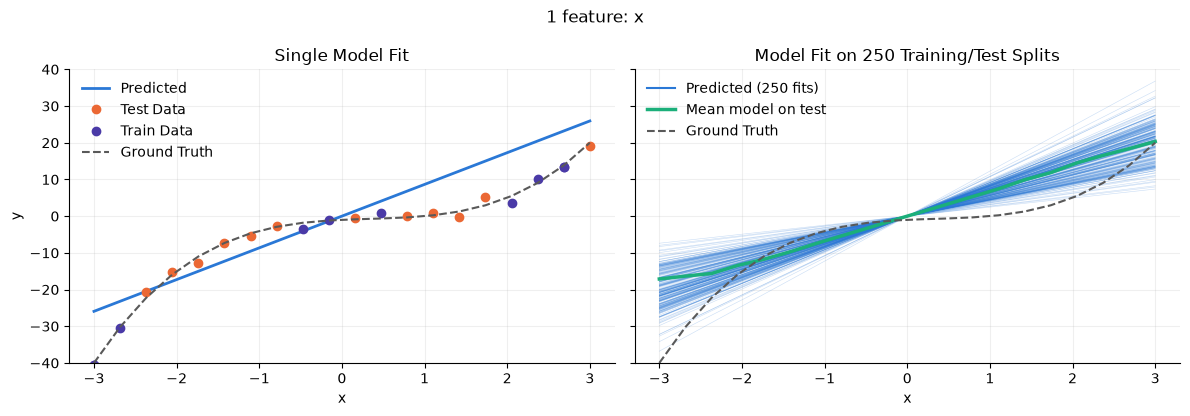

sesgo^2 = 60.20   varianza = 9.80


In [26]:
def repartos(features, L, seed=4, replace=True, x_labels=None, f_true=None):
    # Repeats the train/test split L times. Returns:
    #   test_vals (L, n): prediction on each test point, NaN where the point was in train
    #   curvas    (L, n): the full curve of each fit (for plotting)
    #   last      : (train indices, test indices, w) of the last split
    labels = syn_labels if x_labels is None else x_labels
    n = len(labels)
    rng = np.random.default_rng(seed)
    test_vals = np.full((L, n), np.nan)
    curvas = np.empty((L, n))
    for i in range(L):
        idx = rng.choice(n, size=n // 2, replace=replace)
        test_idx = np.array(sorted(set(range(n)) - set(idx)))
        w, *_ = np.linalg.lstsq(features[idx], labels[idx], rcond=None)
        test_vals[i, test_idx] = np.clip(features[test_idx] @ w, -1000, 1000)
        curvas[i] = features @ w
    return test_vals, curvas, (idx, test_idx, w)


def figura_repartos(features, L, titulo, archivo):
    test_vals, curvas, (idx, test_idx, w) = repartos(features, L)
    f_media = np.nanmean(test_vals, axis=0)  # mean model, evaluated on test points
    fig, axs = plt.subplots(ncols=2, figsize=(12, 4.2), sharey=True)
    axs[0].plot(syn_x, features @ w, color="#2a78d6", linewidth=2, label="Predicted")
    axs[0].plot(syn_x[test_idx], syn_labels[test_idx], "o", color="#eb6834", label="Test Data")
    axs[0].plot(syn_x[idx], syn_labels[idx], "o", color="#4a3aa7", label="Train Data")
    axs[0].set_title("Single Model Fit")
    for c in curvas:
        axs[1].plot(syn_x, c, color="#2a78d6", alpha=0.25, linewidth=0.4)
    axs[1].plot([], [], color="#2a78d6", label=f"Predicted ({L} fits)")
    axs[1].plot(syn_x, f_media, color="#1baf7a", linewidth=2.5, label="Mean model on test")
    axs[1].set_title(f"Model Fit on {L} Training/Test Splits")
    for ax in axs:
        ax.plot(syn_x, syn_f, "--", color="0.35", label="Ground Truth")
        ax.set_ylim(-40, 40)
        ax.set_xlabel("x")
        ax.legend(frameon=False, loc="upper left")
        ax.grid(alpha=0.2)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
    axs[0].set_ylabel("y")
    fig.suptitle(titulo)
    fig.tight_layout()
    fig.savefig(f"../figuras/{archivo}", dpi=150)
    plt.show()
    sesgo2 = np.mean((f_media - syn_f) ** 2)
    varianza = np.nanmean((test_vals - f_media) ** 2)
    print(f"sesgo^2 = {sesgo2:.2f}   varianza = {varianza:.2f}")
    return test_vals


feat_1 = np.vstack([syn_x]).T  # a single feature: x (no intercept)
tv_1 = figura_repartos(feat_1, 250, "1 feature: x", "03_bv_1_feature.png")

**Modelo rígido: mucho sesgo, poca varianza.**

- **Izquierda**: la recta $w\,x$ no puede seguir la forma de S de la cúbica. Se queda corta en los
  extremos ($x = -3$) y se pasa en el centro-derecha, donde $f$ es casi plana.
- **Derecha**: los 250 ajustes forman un **abanico estrecho** que gira alrededor del origen. Cada reparto
  da una pendiente algo distinta, pero todas las rectas se parecen: eso es **poca varianza** (9.80).
- **El modelo medio** (verde) es otra recta y sigue sin parecerse a la curva discontinua. Por muchos
  repartos que promediemos, el error no se va: eso es **mucho sesgo** ($\text{sesgo}^2 = 60.20$, seis
  veces la varianza).

En la analogía de la diana, dardos juntos pero lejos del centro. **Más datos no lo arreglarían**: con
infinitos puntos, la recta media seguiría siendo una recta.

### Un modelo flexible: siete features

El otro extremo son las features del escenario 3 de 3.2.1: $x^0, x^1, \ldots, x^6$, un polinomio de grado
6 con 7 parámetros. El libro usa 1000 repartos. Con unos 8 puntos distintos en train y 7 parámetros, el
ajuste pasa casi por todos los puntos de train, ruido incluido.

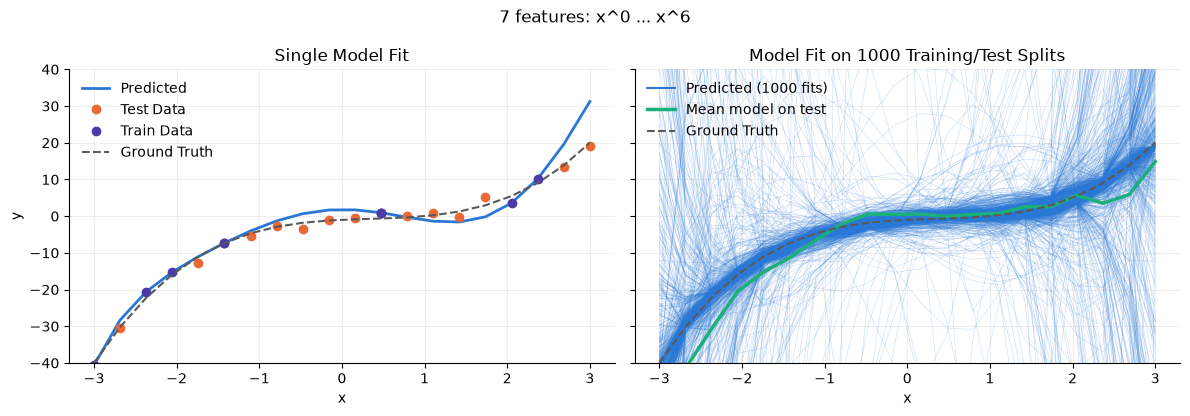

sesgo^2 = 34.10   varianza = 20572.59


In [27]:
feat_7 = np.vstack([syn_x**i for i in range(7)]).T
tv_7 = figura_repartos(feat_7, 1000, "7 features: x^0 ... x^6", "03_bv_7_features.png")

**Modelo flexible: poco sesgo, mucha varianza.**

- **Izquierda**: un único ajuste que se ve razonable, porque pasa cerca de sus puntos de train. Aun así
  ya se separa de la curva verdadera cerca de $x = 3$.
- **Derecha**: la nube de 1000 ajustes cubre **todo** el eje Y en los extremos, porque cada reparto
  dispara la curva hacia un lado distinto. **Varianza = 20 572.59**, más de 2000 veces la del modelo de una
  feature.
- **En el centro**, $x \in [-1, 2]$, la nube se estrecha y el modelo medio (verde) se pega a la curva
  verdadera. Ahí casi todos los repartos tienen puntos de train a ambos lados, así que el modelo
  **interpola**. En los extremos, cuando el punto cae en test, el modelo **extrapola**. Lo medimos punto a
  punto en la última variante.

**Aviso sobre el sesgo² = 34.10.** Con 7 features el modelo contiene a $f$ como caso particular (basta
poner $w_4 = w_5 = w_6 = 0$), así que su sesgo teórico es prácticamente 0. El 34 que sale es **error de
estimación**: calcular una media con valores que oscilan ±1000 necesita muchísimas réplicas. Se ve en el
verde, que se tuerce en los extremos, justo donde la nube es más ancha. Por eso el libro dibuja la
**mediana** en esta figura, que no se deja arrastrar por los valores extremos. Nosotros dejamos la media
porque es lo que aparece en la fórmula.

### El compromiso (*tradeoff*): barrer el número de features

Entre esos dos extremos, el libro prueba de 1 a 5 features ($x^0$; $x^0, x^1$; …; $x^0 \ldots x^4$), con
**2500 repartos** cada uno. Ojo: aquí "1 feature" es $x^0$, la constante (predecir siempre el mismo
número), no $x$ como en la figura anterior. Y con 4 features, $[1, x, x^2, x^3]$, el modelo tiene
exactamente la forma de $f$.

De la fórmula al código (`test_vals` tiene forma `(repartos, puntos)`):

| Término | Fórmula | Código |
|---|---|---|
| Modelo medio $\bar{f}(x)$ | $E_D[\hat{f}(x; D)]$ | `np.nanmean(test_vals, axis=0)` — media por columna (por punto $x$), ignorando los `NaN` |
| Sesgo² | $(f - \bar{f})^2$, promediado sobre $x$ | `np.mean((f_media - syn_f) ** 2)` |
| Varianza | $E_D[(\bar{f} - \hat{f})^2]$, promediada sobre $x$ | `np.nanmean((test_vals - f_media) ** 2)` |
| Error de test | $E[(y - \hat{f})^2]$ | `np.nanmean((test_vals - syn_labels) ** 2)` |

Al final comprobamos la ecuación: el error de test debería ser casi igual a sesgo² + varianza + σ²,
con σ² = 1. Lo de "casi" viene de que solo hay 20 valores de ruido, sorteados una vez: su media del
cuadrado no es exactamente 1.

          sesgo^2  varianza  error test  sesgo^2 + var + 1
features                                                  
1          211.22     19.06      228.33             231.28
2           40.89     11.36       52.04              53.25
3           45.56     40.65       85.08              87.21
4            0.18     14.21       16.11              15.39
5            1.72    605.71      609.02             608.43


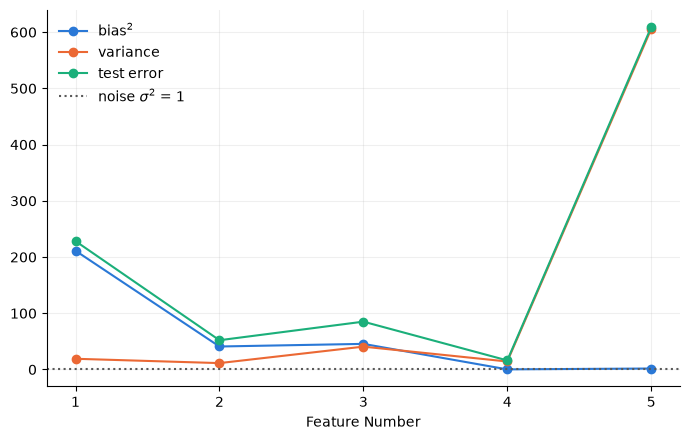

In [28]:
def descomponer(n_features, L=2500, x=syn_x, labels=None, f_true=None, replace=True, seed=4):
    labels = syn_labels if labels is None else labels
    f_true = syn_f if f_true is None else f_true
    feats = np.vstack([x**i for i in range(n_features)]).T
    test_vals, _, _ = repartos(feats, L, seed=seed, replace=replace, x_labels=labels)
    f_media = np.nanmean(test_vals, axis=0)
    return {
        "sesgo^2": np.mean((f_media - f_true) ** 2),
        "varianza": np.nanmean((test_vals - f_media) ** 2),
        "error test": np.nanmean((test_vals - labels) ** 2),
    }


tabla_bv = pd.DataFrame({f: descomponer(f) for f in range(1, 6)}).T
tabla_bv.index.name = "features"
tabla_bv["sesgo^2 + var + 1"] = tabla_bv["sesgo^2"] + tabla_bv["varianza"] + 1
print(tabla_bv.round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tabla_bv.index, tabla_bv["sesgo^2"], "o-", color="#2a78d6", label="bias$^2$")
ax.plot(tabla_bv.index, tabla_bv["varianza"], "o-", color="#eb6834", label="variance")
ax.plot(tabla_bv.index, tabla_bv["error test"], "o-", color="#1baf7a", label="test error")
ax.axhline(1, color="0.35", linestyle=":", label="noise $\\sigma^2$ = 1")
ax.set_xlabel("Feature Number")
ax.set_xticks(tabla_bv.index)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/03_bv_tradeoff.png", dpi=150)
plt.show()

Cómo se lee, fila a fila:

| Features | Qué modelo es | Sesgo² | Varianza | Error test | Diagnóstico |
|---|---|---|---|---|---|
| 1 | $w_0$: una constante | **211.22** | 19.06 | 228.33 | underfitting puro |
| 2 | $w_0 + w_1 x$: una recta | 40.89 | 11.36 | 52.04 | underfitting |
| 3 | parábola | 45.56 | 40.65 | 85.08 | **peor que la recta** |
| **4** | $w_0 + w_1 x + w_2 x^2 + w_3 x^3$: la forma exacta de $f$ | **0.18** | 14.21 | **16.11** | **el óptimo** |
| 5 | grado 4 | 1.72 | **605.71** | 609.02 | overfitting |

Lo principal:

- **La ecuación se cumple.** La última columna de la tabla impresa, sesgo² + varianza + 1, queda a menos de
  3 unidades del error de test en las cinco filas (por ejemplo, 16.11 frente a 15.39 con 4 features). La
  diferencia sale de que el ruido de estos 20 puntos no vale exactamente $\sigma^2 = 1$ (vimos 1.269) y
  de que son 2500 repartos, no infinitos.
- **Mínimo en 4 features, como en el libro.** Es la complejidad justa: el sesgo cae casi a cero (0.18) y
  la varianza aún es moderada.
- **A la izquierda del óptimo manda el sesgo; a la derecha, la varianza.** Con 5 features la varianza se
  multiplica por 43 (14.21 → 605.71) y el sesgo apenas cambia.
- **Aun en el óptimo, el error de test (16.11) es 16 veces el ruido.** Casi todo es varianza (14.21). Con
  unos 8 puntos distintos para 4 parámetros, el modelo sigue siendo inestable. Lo retomamos en la variante.
- **La curva no es una U perfecta.** Con 3 features el error sube respecto a 2 (85.08 frente a 52.04). La
  parábola no reduce el sesgo (40.89 → 45.56), porque no puede representar la parte cúbica que domina en
  los extremos. Y a cambio cuadruplica la varianza. Añadir complejidad no garantiza bajar el sesgo:
  depende de **qué** complejidad añades.

### Lo que concluye el libro

El libro cierra la sección con estas ideas (en nuestras palabras), aquí con los números que las
respaldan en este notebook:

1. **Es la ecuación más importante para entender el entrenamiento en ML.** Ruido, sesgo y varianza
   marcan el mínimo del error de test. El ruido lo ponen los datos; sesgo y varianza, el modelo.
2. **La palanca es la complejidad del modelo**, que en un modelo lineal es el número de features. Al
   subirla baja el sesgo y sube la varianza, y hay un óptimo (aquí, 4 features).
3. **El compromiso es empírico, no un teorema.** La descomposición solo dice que el error *se puede
   partir* en esos términos, no que uno tenga que subir cuando el otro baja. El salto de 2 a 3 features
   (sube la varianza sin que baje el sesgo) es un ejemplo. A veces un modelo mejor baja los dos a la vez.
4. **Más datos reducen la varianza**, y por eso con más datos te puedes permitir modelos más complejos.
   Lo vimos en 3.3: con 500 moléculas ya no había overfitting visible. Lo comprobamos abajo.
5. **Overfitting = poco sesgo y mucha varianza** (la figura de 7 features). **Entrenar poco** (parar
   pronto el descenso de gradiente) sube el sesgo pero baja la varianza, porque los pesos no llegan a
   alejarse mucho del punto de partida. Es lo que pasaba en 3.2 con el mínimo del test en el paso 28.
6. **En deep learning no siempre se cumple.** Las redes grandes pueden añadir parámetros y *bajar* el
   error de test. Ya lo vimos en pequeño en 3.3: el **doble descenso** con 204 descriptores, cuando pasado
   el pico ($f \approx N$) el error volvía a bajar.

### Variante propia: más features, sin reemplazo y con más datos

*(No está en el libro.)*

El libro para en 5 features "porque la varianza se hace muy grande" y afirma que **más datos reducen la
varianza**. Lo comprobamos, y de paso medimos cuánto pesa el sorteo con reemplazo. Tres montajes, de 1 a
7 features, con 2500 repartos cada uno:

1. **Libro**: 20 puntos, train sorteado con reemplazo.
2. **Sin reemplazo**: 20 puntos, train de 10 puntos distintos (`replace=False`).
3. **Más datos**: 100 puntos en el mismo intervalo $[-3, 3]$, con su propio ruido de σ = 1, y con reemplazo
   como el libro.

El eje Y va en **escala logarítmica**: cada marca es 10 veces la anterior. Sin ella, la varianza de 7
features aplastaría todo lo demás contra el cero.

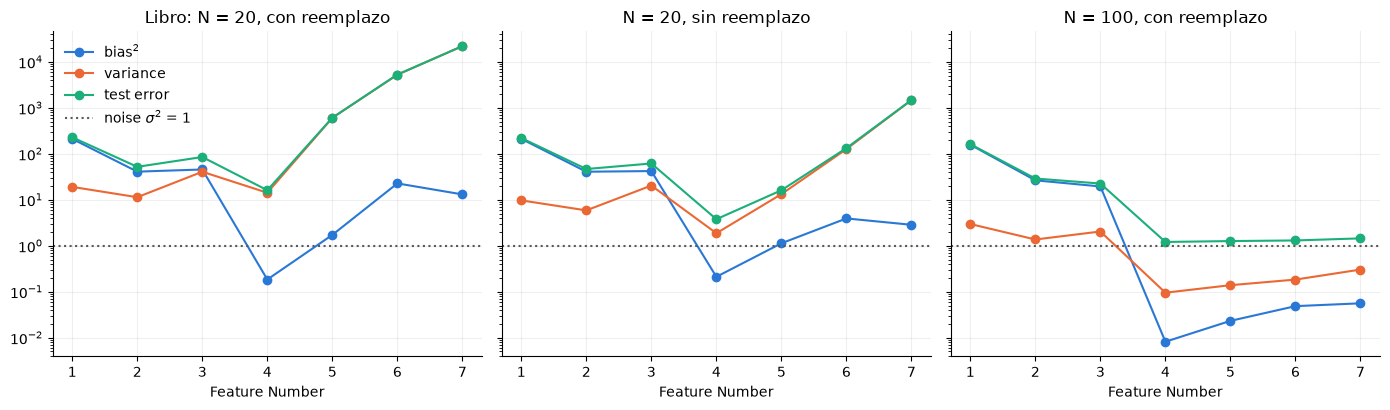


Libro: N = 20, con reemplazo
   sesgo^2  varianza  error test
1   211.22     19.06      228.33
2    40.89     11.36       52.04
3    45.56     40.65       85.08
4     0.18     14.21       16.11
5     1.72    605.71      609.02
6    22.69   5259.26     5284.82
7    13.07  21994.75    22009.00

N = 20, sin reemplazo
   sesgo^2  varianza  error test
1   211.82      9.70      220.11
2    40.74      5.87       46.66
3    42.10     20.38       61.57
4     0.21      1.87        3.77
5     1.13     13.24       16.09
6     3.92    126.58      132.90
7     2.85   1471.73     1476.19

N = 100, con reemplazo
   sesgo^2  varianza  error test
1   157.78      2.97      161.82
2    26.47      1.37       28.96
3    19.49      2.04       22.53
4     0.01      0.10        1.21
5     0.02      0.14        1.26
6     0.05      0.18        1.30
7     0.06      0.30        1.45


In [29]:
x_100 = np.linspace(-3, 3, 100)
f_100 = x_100**3 - x_100**2 + x_100 - 1
labels_100 = f_100 + np.random.default_rng(4).normal(size=100)

montajes = {
    "Libro: N = 20, con reemplazo": dict(),
    "N = 20, sin reemplazo": dict(replace=False),
    "N = 100, con reemplazo": dict(x=x_100, labels=labels_100, f_true=f_100),
}
tablas_var = {}
for nombre, kw in montajes.items():
    tablas_var[nombre] = pd.DataFrame({f: descomponer(f, **kw) for f in range(1, 8)}).T

fig, axs = plt.subplots(ncols=3, figsize=(14, 4.2), sharey=True)
for ax, (nombre, t) in zip(axs, tablas_var.items()):
    ax.plot(t.index, t["sesgo^2"], "o-", color="#2a78d6", label="bias$^2$")
    ax.plot(t.index, t["varianza"], "o-", color="#eb6834", label="variance")
    ax.plot(t.index, t["error test"], "o-", color="#1baf7a", label="test error")
    ax.axhline(1, color="0.35", linestyle=":", label="noise $\\sigma^2$ = 1")
    ax.set_yscale("log")
    ax.set_title(nombre)
    ax.set_xlabel("Feature Number")
    ax.set_xticks(t.index)
    ax.grid(alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axs[0].legend(frameon=False)
fig.tight_layout()
fig.savefig("../figuras/03_bv_variantes.png", dpi=150)
plt.show()

for nombre, t in tablas_var.items():
    print(f"\n{nombre}")
    print(t.round(2).to_string())

**1. Pasado el óptimo, la varianza crece de forma exponencial** (panel izquierdo). En escala
logarítmica es casi una recta: 14.21 → 605.71 → 5259.26 → 21 994.75 al pasar de 4 a 7 features. Por eso
el libro corta en 5. El sesgo² de 6 y 7 features (22.69, 13.07) es el mismo error de estimación de la
figura de 7 features, no sesgo real.

**2. El sorteo con reemplazo infla la varianza** (panel central). Con 10 puntos distintos en lugar de
unos 8:

| Features | Varianza con reemplazo | Varianza sin reemplazo | Error test con / sin |
|---|---|---|---|
| 4 | 14.21 | **1.87** | 16.11 / **3.77** |
| 5 | 605.71 | **13.24** | 609.02 / **16.09** |
| 7 | 21 994.75 | **1471.73** | 22 009.00 / **1476.19** |

El sesgo apenas cambia (0.18 frente a 0.21 con 4 features). La conclusión del libro se mantiene (mínimo
en 4 features, forma de U), pero sus valores de varianza están exagerados. Es una prueba en pequeño de la
idea 4: **dos puntos más ya dividen la varianza entre 7.6** con 4 features.

**3. Con 100 puntos, la varianza casi desaparece** (panel derecho):

- Desde 4 features, el error de test se queda entre **1.21 y 1.45**: prácticamente el suelo del ruido.
  El modelo ya no puede hacerlo mejor.
- Con 7 features, la varianza pasa de **21 994.75** (20 puntos) a **0.30** (100 puntos). Las features de
  sobra casi no penalizan.
- **El sesgo no depende de los datos**: 1 feature sigue en 157.78 y 3 features en 19.49. Un modelo que no
  puede representar $f$ no mejora con más datos (lo que anticipábamos con la recta de una feature).

**Regla práctica:** si tu modelo sobreajusta, más datos ayudan. Si no llega (underfitting), más datos no
sirven, y hace falta un modelo o unas features mejores.

### Variante propia: ¿dónde vive la varianza?

*(No está en el libro.)*

La varianza que hemos dado hasta ahora es una media sobre los 20 puntos. Pero en la fórmula está
definida **punto a punto**. ¿Es parecida en todo el intervalo, o se concentra en algún sitio? La
calculamos para cada $x$ con los montajes de 4 y 5 features del libro:
`np.nanvar(test_vals, axis=0)` es la varianza de cada columna, es decir, de cada punto.

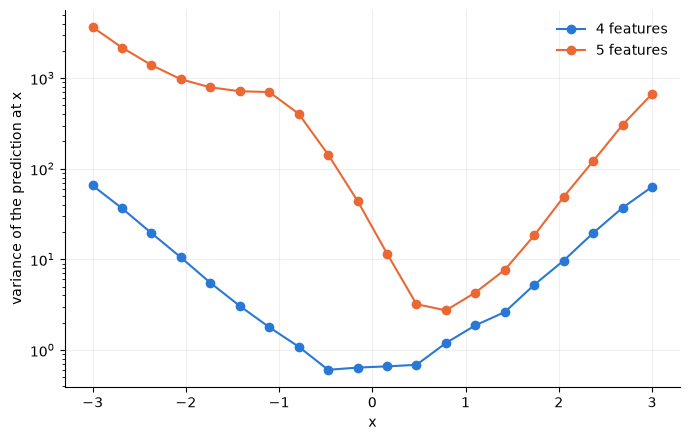

    -3.00   -2.68   -2.37  -2.05  -1.74  -1.42  -1.11  -0.79  -0.47  -0.16   0.16   0.47   0.79   1.11   1.42   1.74   2.05   2.37   2.68   3.00
4    65.3    36.6    19.5   10.5    5.5    3.1    1.8    1.1    0.6    0.6    0.7    0.7    1.2    1.9    2.6    5.2    9.7   19.5   37.1   63.1
5  3651.6  2170.3  1392.1  971.3  790.7  716.6  701.9  403.7  143.2   44.1   11.6    3.2    2.7    4.3    7.7   18.4   49.0  121.3  304.9  670.0


In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5))
var_por_x = {}
for n_f, color in [(4, "#2a78d6"), (5, "#eb6834")]:
    feats = np.vstack([syn_x**i for i in range(n_f)]).T
    tv, _, _ = repartos(feats, 2500)
    var_por_x[n_f] = np.nanvar(tv, axis=0)
    ax.plot(syn_x, var_por_x[n_f], "o-", color=color, label=f"{n_f} features")
ax.set_yscale("log")
ax.set_xlabel("x")
ax.set_ylabel("variance of the prediction at x")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig("../figuras/03_bv_varianza_por_x.png", dpi=150)
plt.show()

print(pd.DataFrame(var_por_x, index=syn_x.round(2)).T.round(1).to_string())

**La varianza vive en los bordes.** Con 4 features vale **0.6** en el centro y **65.3** en
$x = -3$, unas 100 veces más. Con 5 features va de **2.7** a **3651.6**, unas 1350 veces más.

El motivo es el que apuntábamos con la figura de 7 features. Cuando un punto del borde cae en test, el
modelo tiene que **extrapolar** fuera del rango de su train, y un polinomio fuera de sus datos se dispara.
Un punto del centro casi siempre tiene puntos de train a los dos lados, así que el modelo solo
**interpola**.

Es la misma historia de la **rafinosa** en 3.2: 11 dadores de H cuando el máximo en train era 4. Una
molécula fuera del rango del train es una molécula donde la predicción tiene mucha varianza. De ahí sale
la idea de **dominio de aplicabilidad** (3.8): la varianza de un modelo no es una propiedad única, sino
que depende de **dónde** preguntas.

### Resumen de 3.4

- **Error esperado en un dato nuevo = sesgo² + varianza + ruido σ².** Se deduce sumando y restando el
  modelo medio $\bar{f}$. Es la ecuación central del capítulo.
- **Sesgo** = lo lejos que queda de $f$ el modelo medio (error sistemático, la *veracidad* de química
  analítica) → **underfitting**. **Varianza** = cuánto cambia el modelo si cambian los datos de
  entrenamiento (error aleatorio, la *precisión*) → **overfitting**. **Ruido** = el suelo que ponen los
  datos; ningún modelo lo baja.
- Para medirlos hay que **repetir el reparto y reentrenar** cientos de veces (2500 aquí). Con 20 puntos y
  ruido σ = 1:
  - **1 feature ($x$)**: sesgo² 60.20, varianza 9.80.
  - **7 features**: varianza 20 572.59.
  - **Barrido de 1 a 5 features**: mínimo del error de test con **4 features** (16.11), donde el sesgo² es
    0.18.
- **La ecuación se comprueba**: sesgo² + varianza + 1 queda a menos de 3 unidades del error de test.
- **El compromiso no es un teorema**: con 3 features el error sube frente a 2 (85.08 frente a 52.04).
- **El código oculto del libro sortea el train con reemplazo** (unos 8 puntos distintos de 10). Sin
  reemplazo, la varianza con 4 features baja de 14.21 a 1.87.
- *Variante propia*: **más datos reducen la varianza, no el sesgo.** Con 100 puntos, el error de test con 4
  a 7 features se queda entre 1.21 y 1.45 (≈ ruido), pero el sesgo² de 1 feature sigue en 157.78.
- *Variante propia*: **la varianza se concentra en los extremos** (hasta ×100 con 4 features), donde el
  modelo extrapola. Es el caso de la rafinosa, y enlaza con el dominio de aplicabilidad (3.8).
- La media sobre repartos es sensible a los valores extremos: con 7 features el "sesgo²" estimado (34.10)
  es ruido de estimación, no sesgo real.

**Siguiente**: 3.5, *Regularization*. Si la varianza viene de pesos enormes (−413 en 3.2.1, la norma de
$w$ en 3.3), la solución directa es **penalizar los pesos grandes** en la función de pérdida: L2 (*ridge*)
y L1 (*lasso*).